In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

GRID_S = 16                      # celdas por lado del grid
IMG_SIZE = 256                   # tamaño de la imagen de entrada
STRIDE = IMG_SIZE // GRID_S      # 16 px por celda

# Convención de canales de la salida de la cabeza [B, 8, S, S]
CH_OBJ, CH_BOX, CH_CLS = 0, slice(1, 5), slice(5, 8)
CLASS_NAMES = {1: "sacro", 2: "coxal_izquierdo", 3: "coxal_derecho"}

torch 2.14.1+cpu | device: cpu


In [2]:
batch = torch.load("evidencias/batch_fijo.pt")
imgs = batch["imgs"]
targets = [{"boxes": b, "labels": l, "case_id": c, "slice_index": s}
           for b, l, c, s in zip(batch["boxes"], batch["labels"], batch["case_ids"], batch["slice_index"])]

n_por_imagen = [len(t["boxes"]) for t in targets]
print("imgs:", tuple(imgs.shape), "| cajas por imagen:", n_por_imagen, "| total:", sum(n_por_imagen))

assert tuple(imgs.shape) == (6, 1, IMG_SIZE, IMG_SIZE)
assert all(int(t["labels"].min()) >= 1 and int(t["labels"].max()) <= 3 for t in targets), "labels fuera de 1..3"
print("Batch cargado y con el formato esperado.")

imgs: (6, 1, 256, 256) | cajas por imagen: [1, 3, 2, 3, 2, 1] | total: 12
Batch cargado y con el formato esperado.


## 1. IoU: qué tanto se parecen dos cajas

**Qué es.** El IoU (Intersection over Union) mide la superposición entre dos cajas: el área donde se solapan dividida entre el área total que cubren juntas.

$$IoU(A,B)=\frac{\text{área}(A\cap B)}{\text{área}(A\cup B)}$$

Vale 1 si las cajas son idénticas y 0 si no se tocan.

**Para qué lo usamos.** (1) Es la métrica de detección del proyecto (IoU promedio ≥ 0.65). (2) Entra en la pérdida de caja como `1 − IoU`. (3) El NMS de la próxima semana lo usa para decidir si dos cajas son la misma.

**Formato.** Se calcula en formato corners `(x_min, y_min, x_max, y_max)` en píxeles. La cabeza predice en formato centro, y se convierte a corners antes de calcular el IoU.

**Dos detalles que evitan errores silenciosos.**
- `clamp(min=0)`: si las cajas no se tocan, el ancho (o el alto) de la intersección sale negativo; sin el clamp, dos negativos se multiplicarían y darían un área positiva falsa.
- `eps` en el denominador: una caja de área cero daría 0/0 = NaN.

**Ejemplo a mano.** $A=(0,0,10,10)$ y $B=(5,5,15,15)$: la intersección es $5\times5=25$, la unión es $100+100-25=175$, y $IoU=25/175=1/7\approx0.1429$.

In [3]:
def box_iou(boxes1, boxes2, eps=1e-7):
    """IoU elemento a elemento entre cajas xyxy (píxeles). Acepta cualquier forma [..., 4] compatible por broadcasting."""
    boxes1 = boxes1.float()
    boxes2 = boxes2.float()

    # 1) Esquinas del rectángulo de intersección
    inter_x1 = torch.maximum(boxes1[..., 0], boxes2[..., 0])
    inter_y1 = torch.maximum(boxes1[..., 1], boxes2[..., 1])
    inter_x2 = torch.minimum(boxes1[..., 2], boxes2[..., 2])
    inter_y2 = torch.minimum(boxes1[..., 3], boxes2[..., 3])

    # 2) Área de la intersección (clamp: si no se tocan, ancho/alto negativo -> 0)
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    # 3) Área de cada caja
    area1 = (boxes1[..., 2] - boxes1[..., 0]).clamp(min=0) * (boxes1[..., 3] - boxes1[..., 1]).clamp(min=0)
    area2 = (boxes2[..., 2] - boxes2[..., 0]).clamp(min=0) * (boxes2[..., 3] - boxes2[..., 1]).clamp(min=0)

    # 4) Unión = suma de áreas - intersección (para no contarla dos veces)
    union = area1 + area2 - inter_area
    return inter_area / (union + eps)


def pairwise_iou(boxes1, boxes2):
    """Matriz [N, M]: IoU de cada caja de boxes1 contra cada caja de boxes2 (la usará el NMS)."""
    return box_iou(boxes1[:, None, :], boxes2[None, :, :])


# Versión del profesor (Semana 6, para una sola pareja de cajas) -- la usamos como referencia cruzada
def iou_corners(box1, box2):
    x_min_inter = max(box1[0], box2[0]); y_min_inter = max(box1[1], box2[1])
    x_max_inter = min(box1[2], box2[2]); y_max_inter = min(box1[3], box2[3])
    inter_area = max(0.0, x_max_inter - x_min_inter) * max(0.0, y_max_inter - y_min_inter)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

In [5]:
# ---------------- Controles esenciales de la sección 1 ----------------
def check(nombre, obtenido, esperado, tol=1e-5):
    assert abs(obtenido - esperado) < tol, f"FALLA {nombre}: obtenido={obtenido:.6f}, esperado={esperado:.6f}"
    print(f"OK | {nombre:<46} obtenido={obtenido:.6f}  esperado={esperado:.6f}")

def caja(x1, y1, x2, y2):
    return torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

check("1. cajas idénticas", box_iou(caja(0,0,10,10), caja(0,0,10,10)).item(), 1.0)
check("2. sin solapamiento", box_iou(caja(0,0,5,5), caja(10,10,15,15)).item(), 0.0)
check("3. solape parcial = 25/175 = 1/7", box_iou(caja(0,0,10,10), caja(5,5,15,15)).item(), 25/175)

deg = box_iou(caja(5,5,5,5), caja(5,5,5,5))
assert torch.isfinite(deg).all(), "FALLA: una caja de área cero produce NaN"
print("OK | 4. caja de área cero -> sin NaN")

# Referencia cruzada con iou_corners del profesor (cajas desplazadas sin deformarse, para que haya solape real)
torch.manual_seed(SEED)
xy = torch.rand(1000, 2) * 200
wh = torch.rand(1000, 2) * 55 + 1
b1 = torch.cat([xy, xy + wh], dim=1)
shift = torch.randn(1000, 2) * 5
b3 = b1 + torch.cat([shift, shift], dim=1)
ref = torch.tensor([iou_corners(p, q) for p, q in zip(b1.tolist(), b3.tolist())])
dif = (box_iou(b1, b3) - ref).abs().max().item()
assert dif < 1e-5, f"FALLA: difiere de la versión del profesor en {dif:.2e}"
print(f"OK | 5. igual a iou_corners del profesor (diferencia máxima {dif:.1e})")

OK | 1. cajas idénticas                             obtenido=1.000000  esperado=1.000000
OK | 2. sin solapamiento                            obtenido=0.000000  esperado=0.000000
OK | 3. solape parcial = 25/175 = 1/7               obtenido=0.142857  esperado=0.142857
OK | 4. caja de área cero -> sin NaN
OK | 5. igual a iou_corners del profesor (diferencia máxima 2.4e-07)


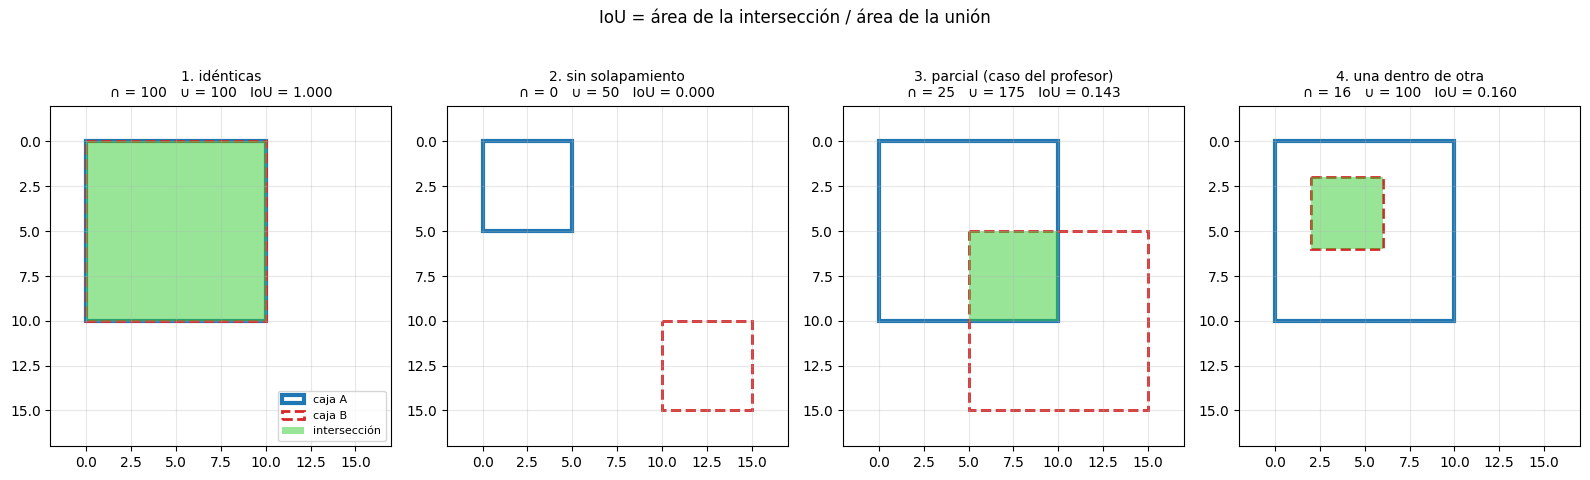

Sin clamp: ancho=-5, alto=-5 -> 'área' = 25  (dos negativos dan un positivo falso)
IoU falso = 1.0  <- diría que las cajas son idénticas


In [6]:
def dibujar_par_iou(ax, A, B, titulo):
    xa1, ya1, xa2, ya2 = A
    xb1, yb1, xb2, yb2 = B
    ax.add_patch(Rectangle((xa1, ya1), xa2 - xa1, ya2 - ya1, fill=False, ec="tab:blue", lw=3, label="caja A"))
    ax.add_patch(Rectangle((xb1, yb1), xb2 - xb1, yb2 - yb1, fill=False, ec="tab:red", lw=2, ls="--", label="caja B"))
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter > 0:
        ax.add_patch(Rectangle((ix1, iy1), ix2 - ix1, iy2 - iy1, fc="limegreen", alpha=0.5, ec="none", label="intersección"))
    union = (xa2 - xa1) * (ya2 - ya1) + (xb2 - xb1) * (yb2 - yb1) - inter
    iou = box_iou(caja(*A), caja(*B)).item()          # el IoU que calcula TU función
    ax.set_xlim(-2, 17)
    ax.set_ylim(17, -2)                               # eje y hacia abajo, como en una imagen
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_title(f"{titulo}\n∩ = {inter:g}   ∪ = {union:g}   IoU = {iou:.3f}", fontsize=10)

pares = [((0, 0, 10, 10), (0, 0, 10, 10), "1. idénticas"),
         ((0, 0, 5, 5), (10, 10, 15, 15), "2. sin solapamiento"),
         ((0, 0, 10, 10), (5, 5, 15, 15), "3. parcial (caso del profesor)"),
         ((0, 0, 10, 10), (2, 2, 6, 6), "4. una dentro de otra")]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.8))
for ax, (A, B, titulo) in zip(axes, pares):
    dibujar_par_iou(ax, A, B, titulo)
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("IoU = área de la intersección / área de la unión", y=1.02)
plt.tight_layout()
plt.show()

# Qué pasaría SIN el clamp en el caso 2 (el error que ese control atrapa)
w = min(5, 15) - max(0, 10)     # ancho de la "intersección" entre (0,0,5,5) y (10,10,15,15)
h = min(5, 15) - max(0, 10)
print(f"Sin clamp: ancho={w}, alto={h} -> 'área' = {w * h}  (dos negativos dan un positivo falso)")
print(f"IoU falso = {(w * h) / (25 + 25 - w * h):.1f}  <- diría que las cajas son idénticas")

## 2. Codificar y decodificar cajas

**El problema.** El dataset entrega cada caja en formato corners, `(x_min, y_min, x_max, y_max)` en píxeles. La cabeza de la red, en cambio, predice **cuatro números por celda** del grid. Hace falta un traductor de ida (caja → números de la celda) y otro de vuelta (números → caja).

**Formato centro.** Igual que en la Semana 6, la cabeza predice en formato centro y el IoU convierte a corners:

$$c_x=\frac{x_{min}+x_{max}}{2} \quad c_y=\frac{y_{min}+y_{max}}{2} \quad w=x_{max}-x_{min} \quad h=y_{max}-y_{min}$$

**Qué codifica cada celda** (imagen de 256 px, grid de 16×16, cada celda mide 16 px):
- **Celda responsable:** la que contiene el centro, `col = floor(c_x / 16)` y `row = floor(c_y / 16)`.
- **tx, ty:** posición del centro dentro de su celda, `tx = c_x/16 − col` y `ty = c_y/16 − row`, ambos en $[0,1)$.
- **tw, th:** tamaño relativo a la imagen, `tw = w/256` y `th = h/256`, ambos en $(0,1]$.

**Por qué así.**
1. Las celdas comparten los mismos pesos (es una convolución). A todas les conviene responder lo mismo: "el centro está a esta fracción dentro de mí". Si cada celda predijera coordenadas de 0 a 256, tendría que aprender un rango distinto.
2. Los cuatro valores quedan en $[0,1]$, que es justo el rango de una sigmoide. Así la cabeza puede predecirlos con sigmoide, como la caja acotada del notebook del profesor.

**Ejemplo a mano.** Caja $(40,50,104,114)$: centro $(72,82)$ y tamaño $64\times64$. Entonces $72/16=4.5$ da `col = 4` y `tx = 0.5`; $82/16=5.125$ da `row = 5` y `ty = 0.125$; y `tw = th = 64/256 = 0.25`.

In [7]:
def encode_boxes(boxes_xyxy, img_size=IMG_SIZE, grid_s=GRID_S):
    """Cajas xyxy en píxeles [N,4] -> (row [N], col [N], targets [N,4] = tx, ty, tw, th en [0,1])."""
    stride = img_size / grid_s
    b = boxes_xyxy.float()
    cx, cy = (b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2
    w, h = b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]

    # celda responsable: la que contiene el centro (clamp por si el centro cae justo en el borde)
    col = (cx / stride).floor().clamp(0, grid_s - 1).long()
    row = (cy / stride).floor().clamp(0, grid_s - 1).long()

    tx = cx / stride - col                      # posición del centro DENTRO de la celda
    ty = cy / stride - row
    tw, th = w / img_size, h / img_size         # tamaño relativo a la imagen
    return row, col, torch.stack([tx, ty, tw, th], dim=1)


def decode_boxes(row, col, t, img_size=IMG_SIZE, grid_s=GRID_S):
    """Inversa de encode_boxes: (row, col, t = [tx, ty, tw, th]) -> cajas xyxy en píxeles [N,4]."""
    stride = img_size / grid_s
    cx = (col.float() + t[:, 0]) * stride
    cy = (row.float() + t[:, 1]) * stride
    w, h = t[:, 2] * img_size, t[:, 3] * img_size
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=1)

In [8]:
# ---------------- Controles esenciales de la sección 2 ----------------
# 1) Caso a mano: caja (40,50,104,114)
r, c, t = encode_boxes(torch.tensor([[40., 50., 104., 114.]]))
esperado = torch.tensor([[0.5, 0.125, 0.25, 0.25]])
assert (r.item(), c.item()) == (5, 4), f"FALLA: celda obtenida (fila {r.item()}, col {c.item()}), esperada (5, 4)"
assert torch.allclose(t, esperado, atol=1e-6), f"FALLA: tx,ty,tw,th = {t.tolist()}"
print(f"OK | 1. caja a mano: celda (fila 5, col 4) y [tx, ty, tw, th] = {t.squeeze().tolist()}")

# 2) Ida y vuelta con las 12 cajas reales del batch
todas = torch.cat([t_["boxes"] for t_ in targets]).float()
rows, cols, tt = encode_boxes(todas)
dec = decode_boxes(rows, cols, tt)
err = (dec - todas).abs().max().item()
iou_min = box_iou(dec, todas).min().item()
assert err < 1e-3, f"FALLA: error de ida y vuelta = {err:.2e} px"
assert iou_min > 0.9999, f"FALLA: IoU mínimo de ida y vuelta = {iou_min:.6f}"
print(f"OK | 2. ida y vuelta con {len(todas)} cajas reales: error máx. = {err:.1e} px, IoU mínimo = {iou_min:.6f}")

# 3) Los valores codificados caen en los rangos que una sigmoide puede producir
assert int(rows.min()) >= 0 and int(rows.max()) <= GRID_S - 1 and int(cols.min()) >= 0 and int(cols.max()) <= GRID_S - 1
assert bool((tt[:, :2] >= 0).all() and (tt[:, :2] < 1).all()), "FALLA: tx, ty fuera de [0,1)"
assert bool((tt[:, 2:] > 0).all() and (tt[:, 2:] <= 1).all()), "FALLA: tw, th fuera de (0,1]"
print(f"OK | 3. rangos: tx,ty en [{tt[:, :2].min():.3f}, {tt[:, :2].max():.3f}] | tw,th en [{tt[:, 2:].min():.3f}, {tt[:, 2:].max():.3f}] | fila/col en [0, {GRID_S - 1}]")

OK | 1. caja a mano: celda (fila 5, col 4) y [tx, ty, tw, th] = [0.5, 0.125, 0.25, 0.25]
OK | 2. ida y vuelta con 12 cajas reales: error máx. = 0.0e+00 px, IoU mínimo = 1.000000
OK | 3. rangos: tx,ty en [0.062, 0.938] | tw,th en [0.008, 0.242] | fila/col en [0, 15]


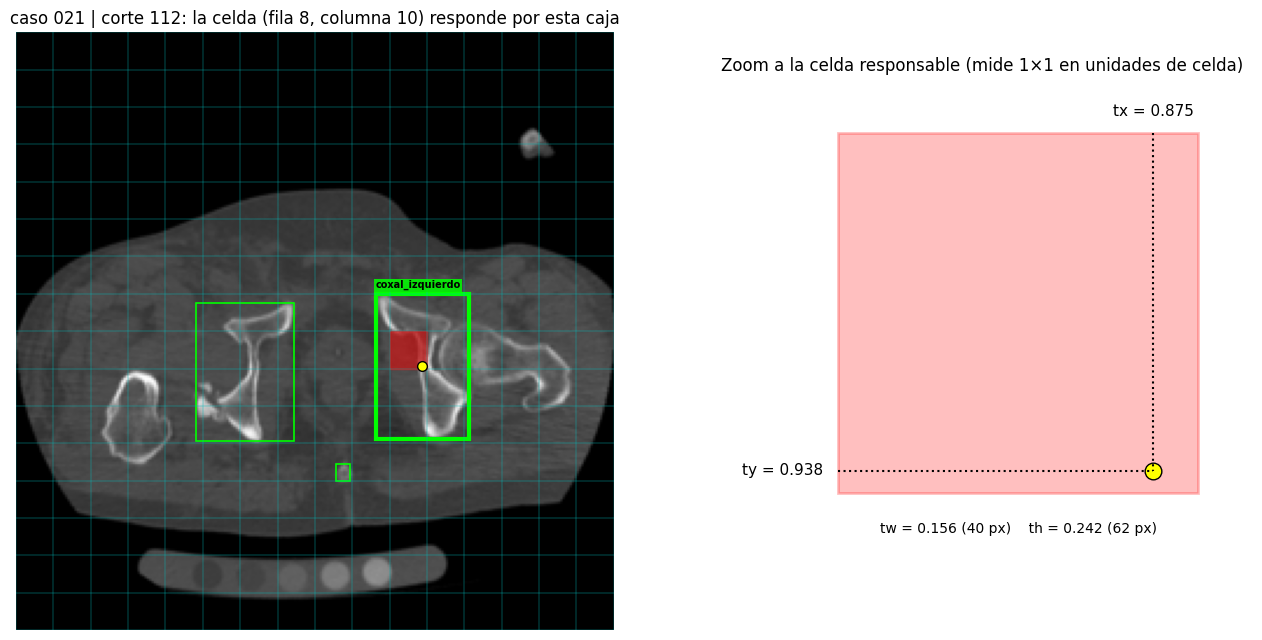

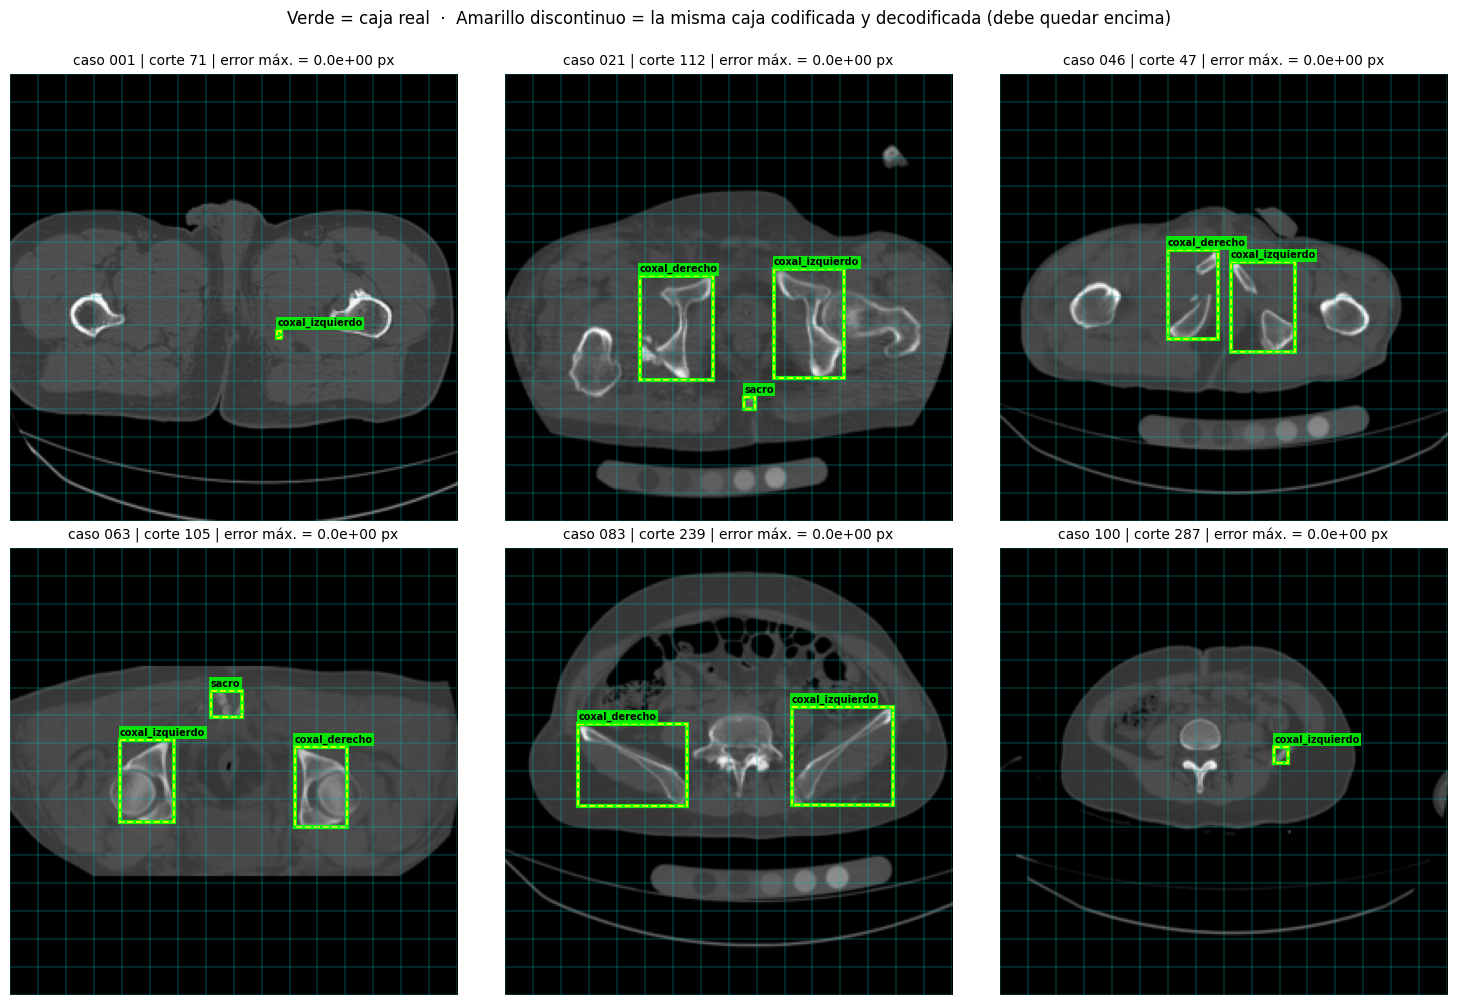

In [10]:
def dibujar_grid(ax):
    for g in range(0, IMG_SIZE + 1, STRIDE):
        ax.axhline(g - 0.5, lw=0.3, c="c")      # -0.5: imshow centra cada píxel en su coordenada entera
        ax.axvline(g - 0.5, lw=0.3, c="c")

def dibujar_caja(ax, caja_xyxy, color, lw=2, ls="-", texto=None):
    x1, y1, x2, y2 = [float(v) for v in caja_xyxy]
    ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), x2 - x1, y2 - y1, fill=False, ec=color, lw=lw, ls=ls))
    if texto:
        ax.text(x1 - 0.5, max(y1 - 3, 6), texto, color="black", fontsize=7, weight="bold",
                bbox=dict(boxstyle="square,pad=0.15", fc=color, ec="none", alpha=0.85))


# ---- Figura 1: una caja paso a paso (la más grande de la imagen 1) ----
k = 1
t = targets[k]
boxes = t["boxes"].float()
row, col, tt = encode_boxes(boxes)
areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
j = int(areas.argmax())
r, c = int(row[j]), int(col[j])
tx, ty, tw, th = [float(v) for v in tt[j]]
x1, y1, x2, y2 = [float(v) for v in boxes[j]]
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
dibujar_grid(ax1)
for b in boxes:
    dibujar_caja(ax1, b, "lime", lw=1.2)
dibujar_caja(ax1, boxes[j], "lime", lw=3, texto=CLASS_NAMES[int(t["labels"][j])])
ax1.add_patch(Rectangle((c * STRIDE - 0.5, r * STRIDE - 0.5), STRIDE, STRIDE, fc="red", alpha=0.5, ec="red"))
ax1.plot(cx - 0.5, cy - 0.5, "o", color="yellow", ms=7, mec="black")
ax1.set_title(f"caso {t['case_id']} | corte {t['slice_index']}: la celda (fila {r}, columna {c}) responde por esta caja")
ax1.axis("off")

ax2.add_patch(Rectangle((0, 0), 1, 1, fc="red", alpha=0.25, ec="red", lw=2))
ax2.plot(tx, ty, "o", color="yellow", ms=12, mec="black")
ax2.plot([tx, tx], [0, ty], ls=":", c="k")
ax2.plot([0, tx], [ty, ty], ls=":", c="k")
ax2.text(tx, -0.04, f"tx = {tx:.3f}", ha="center", va="bottom", fontsize=11)
ax2.text(-0.04, ty, f"ty = {ty:.3f}", ha="right", va="center", fontsize=11)
ax2.text(0.5, 1.08, f"tw = {tw:.3f} ({tw * IMG_SIZE:.0f} px)    th = {th:.3f} ({th * IMG_SIZE:.0f} px)", ha="center", va="top", fontsize=10)
ax2.set_xlim(-0.35, 1.15)
ax2.set_ylim(1.25, -0.15)
ax2.set_aspect("equal")
ax2.axis("off")
ax2.set_title("Zoom a la celda responsable (mide 1×1 en unidades de celda)")
plt.tight_layout()
plt.show()

# ---- Figura 2: ida y vuelta sobre las 6 imágenes reales ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for k, ax in zip(range(len(targets)), axes.ravel()):
    t = targets[k]
    boxes = t["boxes"].float()
    row, col, tt = encode_boxes(boxes)
    dec = decode_boxes(row, col, tt)
    err = float((dec - boxes).abs().max())
    ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
    dibujar_grid(ax)
    for b, lab in zip(boxes, t["labels"]):
        dibujar_caja(ax, b, "lime", lw=3, texto=CLASS_NAMES[int(lab)])
    for d in dec:
        dibujar_caja(ax, d, "yellow", lw=1.2, ls="--")
    ax.set_title(f"caso {t['case_id']} | corte {t['slice_index']} | error máx. = {err:.1e} px", fontsize=10)
    ax.axis("off")
plt.suptitle("Verde = caja real  ·  Amarillo discontinuo = la misma caja codificada y decodificada (debe quedar encima)", y=1.0)
plt.tight_layout()
plt.show()

## 3. Asignación de celdas: qué debe responder cada celda

**Idea.** Cada celda del grid debe responder tres preguntas: ¿hay un objeto cuyo centro está en mí?, ¿dónde está su caja? y ¿de qué clase es? Para entrenar necesitamos esa respuesta correcta celda por celda, en tres tensores del mismo tamaño que la salida de la red:

| Tensor | Forma | Contenido |
|---|---|---|
| `obj_t` | `[B, 16, 16]` | 1 en la celda responsable de una caja, 0 en el fondo |
| `box_t` | `[B, 16, 16, 4]` | `tx, ty, tw, th` de esa caja (ceros en el fondo) |
| `cls_t` | `[B, 16, 16]` | clase 0, 1 o 2 en celdas positivas, **−1** en el fondo |

**Regla de asignación.** La celda que contiene el centro de la caja es la responsable. Todas las demás son fondo. A diferencia del RPN del Taller 3, aquí **no se usa IoU para asignar**: no hay anclas, así que la posición del centro decide.

**Tres decisiones.**
1. **Clases:** el dataset usa 1, 2, 3 y aquí se restan 1 para obtener 0, 1, 2. Si llega un label fuera de 1–3, se lanza un error en vez de aprender mal en silencio.
2. **Colisiones:** si dos centros caen en la misma celda, solo cabe una caja. Gana la de mayor área y se cuenta la colisión.
3. **Fondo = −1 en `cls_t`:** deja una marca visible. Si la pérdida de clase tocara celdas vacías, lo notaríamos.

**Por qué importa.** En este batch solo ~1 de cada 128 celdas es positiva. Ese desbalance condiciona cómo se diseña la pérdida de objectness (sección 5).

In [12]:
def build_targets(targets, grid_s=GRID_S, img_size=IMG_SIZE, num_classes=3):
    """targets: lista (largo B) de dicts con 'boxes' [N,4] xyxy en px y 'labels' [N] con valores 1..num_classes.
    Devuelve tensores densos para la pérdida (en CPU): obj_t [B,S,S], box_t [B,S,S,4], cls_t [B,S,S] (-1 en el fondo)
    y n_collisions (cajas que cayeron en una celda ya ocupada; gana la de mayor área)."""
    B = len(targets)
    obj_t = torch.zeros(B, grid_s, grid_s)
    box_t = torch.zeros(B, grid_s, grid_s, 4)
    cls_t = torch.full((B, grid_s, grid_s), -1, dtype=torch.long)
    n_collisions = 0

    for b, tgt in enumerate(targets):
        boxes = torch.as_tensor(tgt["boxes"]).float().reshape(-1, 4)
        labels = torch.as_tensor(tgt["labels"]).long().reshape(-1)
        if boxes.shape[0] == 0:
            continue                                   # imagen sin cajas: todo queda como fondo
        if labels.min() < 1 or labels.max() > num_classes:
            raise ValueError(f"labels fuera de 1..{num_classes}: {labels.tolist()}")

        row, col, t = encode_boxes(boxes, img_size, grid_s)
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        # De menor a mayor área: la caja más grande se escribe al final, así que "gana" en una colisión
        for k in torch.argsort(areas, stable=True).tolist():
            i, j = row[k].item(), col[k].item()
            if obj_t[b, i, j] == 1:
                n_collisions += 1
            obj_t[b, i, j] = 1
            box_t[b, i, j] = t[k]
            cls_t[b, i, j] = labels[k] - 1             # 1..3 -> 0..2

    return {"obj_t": obj_t, "box_t": box_t, "cls_t": cls_t, "n_collisions": n_collisions}

In [13]:
# ---------------- Controles esenciales de la sección 3 ----------------
img_A = {"boxes": torch.tensor([[104., 90., 152., 170.], [30., 60., 90., 180.], [170., 60., 230., 180.]]),
         "labels": torch.tensor([1, 2, 3])}            # tres regiones, sin colisión
img_B = {"boxes": torch.tensor([[100., 100., 160., 160.], [124., 124., 140., 140.]]),
         "labels": torch.tensor([1, 2])}               # dos centros en la misma celda (8, 8)
img_C = {"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.long)}   # sin cajas

# 1) Imagen A calculada a mano: celdas, clases y valores
TA = build_targets([img_A])
rr, cc = TA["obj_t"][0].nonzero(as_tuple=True)
pos = sorted(zip(rr.tolist(), cc.tolist()))
assert pos == [(7, 3), (7, 12), (8, 8)], f"FALLA: celdas positivas = {pos}"
clases = [TA["cls_t"][0, i, j].item() for i, j in pos]
assert clases == [1, 2, 0], f"FALLA: clases = {clases}"
assert torch.allclose(TA["box_t"][0, 8, 8], torch.tensor([0., 0.125, 0.1875, 0.3125])), "FALLA: box_t en (8,8)"
print(f"OK | 1. a mano: celdas {pos}, clases (0..2) {clases}, box_t(8,8) = {TA['box_t'][0, 8, 8].tolist()}")

# 2) Colisión: se cuenta y gana la caja grande
TB = build_targets([img_B])
assert TB["n_collisions"] == 1, f"FALLA: colisiones = {TB['n_collisions']}"
assert TB["obj_t"].sum().item() == 1 and TB["cls_t"][0, 8, 8].item() == 0, "FALLA: debía ganar la caja grande (clase 0)"
assert torch.allclose(TB["box_t"][0, 8, 8], torch.tensor([0.125, 0.125, 0.234375, 0.234375])), "FALLA: box_t no es el de la caja grande"
print("OK | 2. colisión: contada (=1) y gana la caja grande")

# 3) Imagen sin cajas
TC = build_targets([img_C])
assert TC["obj_t"].sum().item() == 0 and bool((TC["cls_t"] == -1).all()) and TC["n_collisions"] == 0, "FALLA: imagen vacía"
print("OK | 3. imagen sin cajas: sin positivas, cls_t todo -1")

# 4) Con el batch real: cuentas y coherencia
T = build_targets(targets)
n_cajas = sum(len(t_["boxes"]) for t_ in targets)
n_pos = int(T["obj_t"].sum())
assert n_cajas == n_pos + T["n_collisions"], f"FALLA: {n_cajas} cajas != {n_pos} positivas + {T['n_collisions']} colisiones"
assert bool(((T["obj_t"] == 1) == (T["cls_t"] >= 0)).all()), "FALLA: obj_t y cls_t no coinciden"
print(f"OK | 4. batch real: {n_cajas} cajas = {n_pos} celdas positivas + {T['n_collisions']} colisiones; obj_t y cls_t coinciden")

# 5) Labels inválidos deben lanzar error
for malo in (0, 4):
    try:
        build_targets([{"boxes": img_A["boxes"][:1], "labels": torch.tensor([malo])}])
        raise AssertionError(f"FALLA: el label {malo} no lanzó ValueError")
    except ValueError:
        pass
print("OK | 5. label 0 y label 4 lanzan ValueError")

OK | 1. a mano: celdas [(7, 3), (7, 12), (8, 8)], clases (0..2) [1, 2, 0], box_t(8,8) = [0.0, 0.125, 0.1875, 0.3125]
OK | 2. colisión: contada (=1) y gana la caja grande
OK | 3. imagen sin cajas: sin positivas, cls_t todo -1
OK | 4. batch real: 12 cajas = 12 celdas positivas + 0 colisiones; obj_t y cls_t coinciden
OK | 5. label 0 y label 4 lanzan ValueError


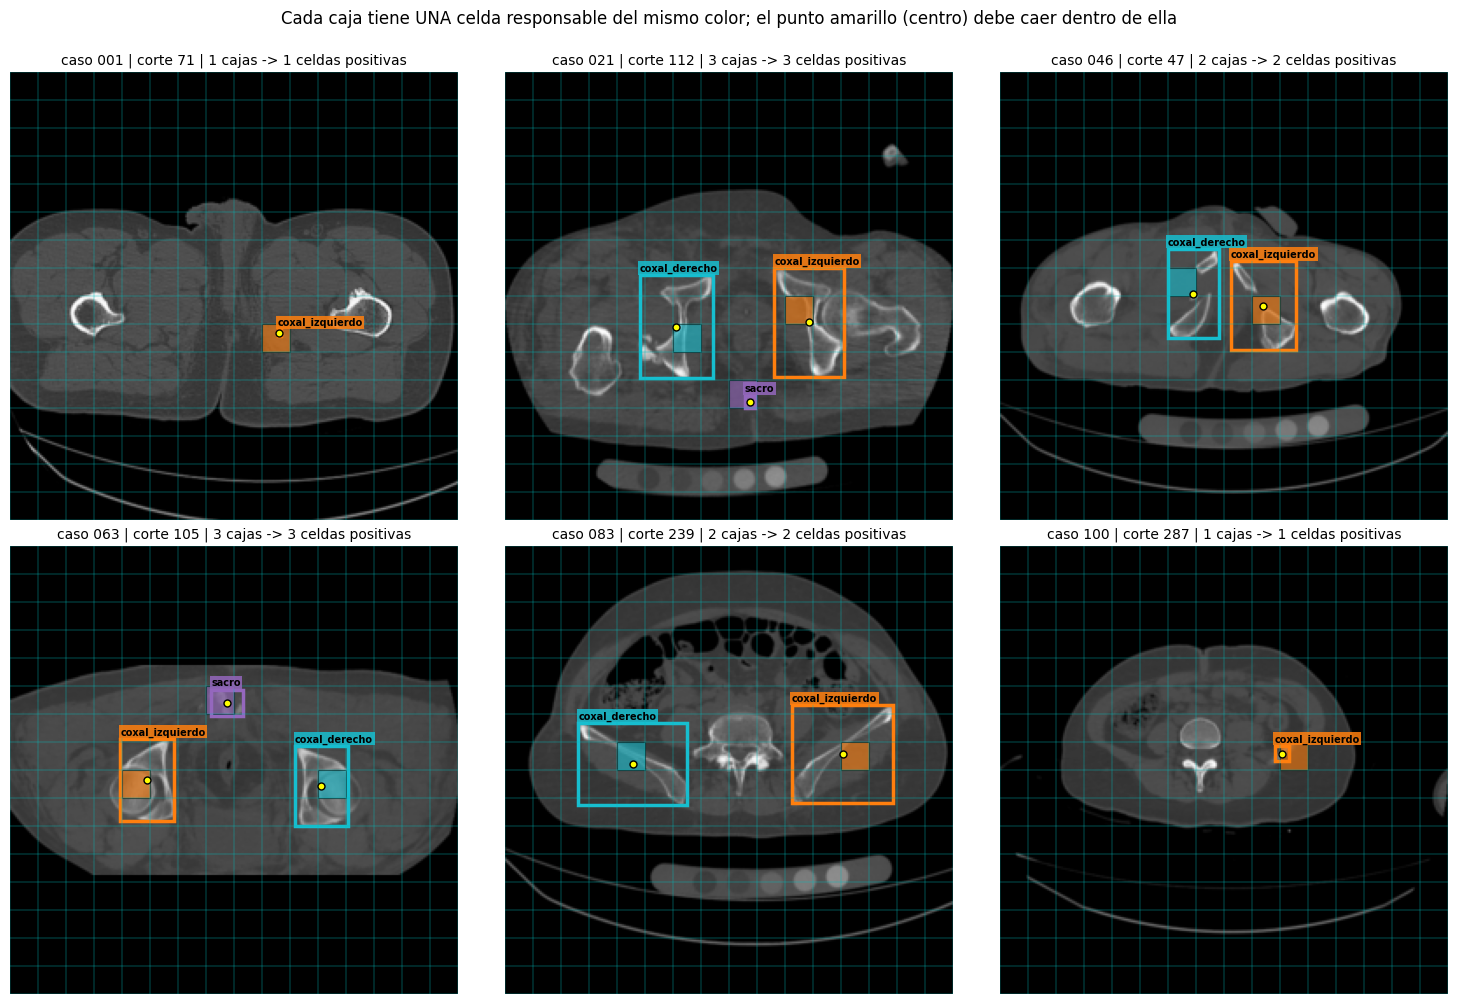

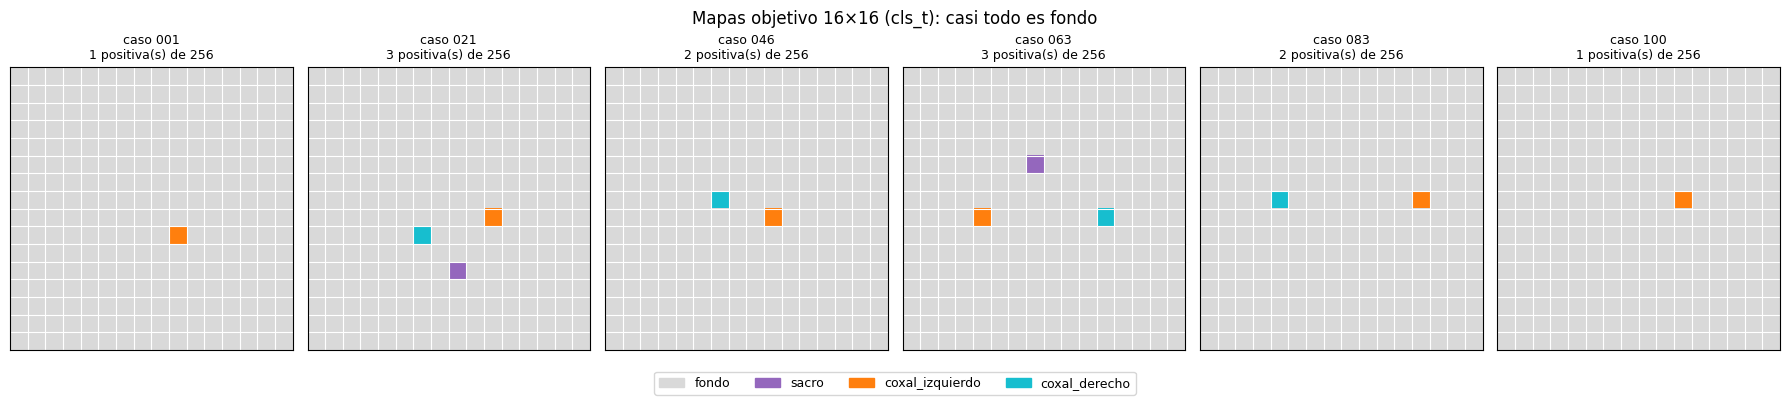

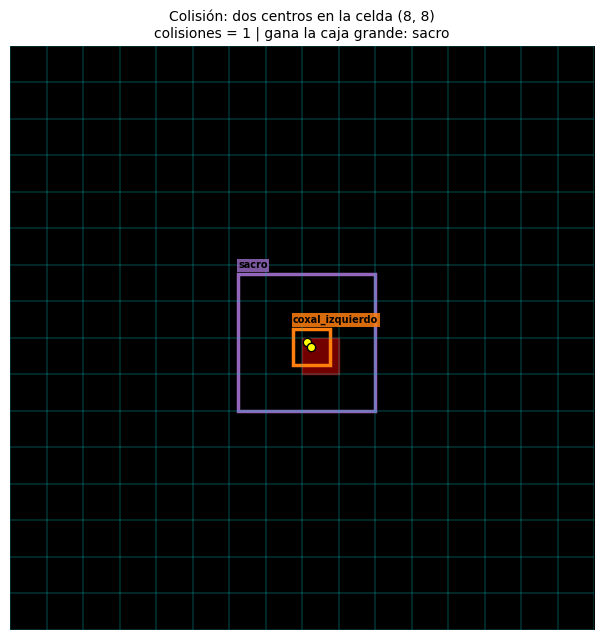

Celdas positivas por clase en el batch real:
  sacro            2
  coxal_izquierdo  6
  coxal_derecho    4
Fracción de celdas positivas: 0.0078  (≈ 1 de cada 128)  |  colisiones: 0


In [ ]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

COLORES_CLASE = {1: "#9467bd", 2: "#ff7f0e", 3: "#17becf"}   # sacro, coxal izquierdo, coxal derecho

# ---- Figura A: cada caja con su celda responsable (mismo color = misma clase) ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for k, ax in zip(range(len(targets)), axes.ravel()):
    t = targets[k]
    ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
    dibujar_grid(ax)
    for i, j in T["obj_t"][k].nonzero().tolist():
        cl = int(T["cls_t"][k, i, j]) + 1                        # de vuelta a 1..3, solo para elegir el color
        ax.add_patch(Rectangle((j * STRIDE - 0.5, i * STRIDE - 0.5), STRIDE, STRIDE, fc=COLORES_CLASE[cl], alpha=0.6, ec="black", lw=0.8))
    for b, lab in zip(t["boxes"], t["labels"]):
        dibujar_caja(ax, b, COLORES_CLASE[int(lab)], lw=2.5, texto=CLASS_NAMES[int(lab)])
        ax.plot((float(b[0]) + float(b[2])) / 2 - 0.5, (float(b[1]) + float(b[3])) / 2 - 0.5, "o", color="yellow", ms=5, mec="black")
    n = int(T["obj_t"][k].sum())
    ax.set_title(f"caso {t['case_id']} | corte {t['slice_index']} | {len(t['boxes'])} cajas -> {n} celdas positivas", fontsize=10)
    ax.axis("off")
plt.suptitle("Cada caja tiene UNA celda responsable del mismo color; el punto amarillo (centro) debe caer dentro de ella", y=1.0)
plt.tight_layout()
plt.show()

# ---- Figura B: lo que la red debe producir (el mapa cls_t de cada imagen) ----
cmap = ListedColormap(["#d9d9d9"] + [COLORES_CLASE[c] for c in (1, 2, 3)])
fig, axes = plt.subplots(1, 6, figsize=(18, 3.8))
for k, ax in zip(range(len(targets)), axes):
    ax.imshow(np.asarray(T["cls_t"][k]) + 1, cmap=cmap, vmin=0, vmax=3)     # fondo (-1) -> 0 ; clases 0..2 -> 1..3
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticks(np.arange(-0.5, GRID_S, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_S, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="both", length=0)
    ax.set_title(f"caso {targets[k]['case_id']}\n{int(T['obj_t'][k].sum())} positiva(s) de {GRID_S * GRID_S}", fontsize=9)
fig.legend(handles=[Patch(color="#d9d9d9", label="fondo")] + [Patch(color=COLORES_CLASE[c], label=CLASS_NAMES[c]) for c in (1, 2, 3)],
           loc="lower center", ncol=4, fontsize=9)
plt.suptitle("Mapas objetivo 16×16 (cls_t): casi todo es fondo", y=1.02)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

# ---- Resumen del batch real ----
print("Celdas positivas por clase en el batch real:")
for cl in (1, 2, 3):
    print(f"  {CLASS_NAMES[cl]:<16} {int((T['cls_t'] == cl - 1).sum())}")
frac = T["obj_t"].mean().item()
print(f"Fracción de celdas positivas: {frac:.4f}  (≈ 1 de cada {1 / frac:.0f})  |  colisiones: {T['n_collisions']}")

## 4. La cabeza de detección

**Qué recibe y qué entrega.** Recibe el mapa de características del backbone (con el CBAM) de forma `[B, 256, 16, 16]` y entrega **logits crudos** `[B, 8, 16, 16]`: ocho números por celda.

| Canal | Contenido |
|---|---|
| 0 | objectness (¿hay un hueso con su centro aquí?) |
| 1–4 | `tx, ty, tw, th` de la caja |
| 5–7 | clase: sacro, coxal izquierdo, coxal derecho |

**Sin activaciones en la salida.** La sigmoide y el softmax se aplican después, en la pérdida y al decodificar. Es el mismo criterio del profesor: la clase sale sin activación porque la entropía cruzada espera logits crudos, y la caja se acota con sigmoide porque `tx, ty, tw, th` viven en [0, 1].

**Arquitectura: conv 3×3 → GroupNorm → ReLU → conv 1×1.**
- La **3×3** deja que cada celda mire a sus vecinas. Con cajas de hasta 62 px (casi 4 celdas), una celda aislada no vería el hueso completo.
- **GroupNorm** no depende del tamaño del batch ni guarda estadísticas acumuladas, así que no tiene la brecha entre entrenamiento y evaluación que Miguel midió con BatchNorm (98.6 %).
- La **1×1** reduce 128 canales a los 8 de salida.

**Sesgos iniciales (priors).** Sin ellos, la red arranca con P(objeto) ≈ 50 % en las 256 celdas y la pérdida la dominan los falsos positivos.
- **Objectness:** fracción real de celdas positivas (la que medimos en la sección 3). Es la misma idea del −2.19 que usa el CenterNet del profesor.
- **tw, th:** tamaño inicial de la caja por celda, elegido por **cobertura**: qué tamaño cuadrado se parece más, en promedio, a las cajas reales. Es el equivalente a comparar escalas de anclas. Aquí no hay anclas: cada celda arranca con una sola caja por defecto y la red la ajusta.
- **tx, ty = 0:** el centro de la celda.

Para que esta sección no dependa de Miguel ni de Annie, usamos un mapa de características **aleatorio y fijo**. El backbone real se conecta al integrar.

   wh  lado (px)  mejor IoU medio   mediana
 0.05       12.8            0.126     0.087
 0.08       20.5            0.199     0.169
 0.13       33.3            0.330     0.380
 0.15       38.4            0.387     0.476
 0.20       51.2            0.418     0.526
 0.25       64.0            0.340     0.356
 0.30       76.8            0.250     0.247

OBJ_PRIOR = 0.0078 (fracción real de celdas positivas) | WH_PRIOR = 0.2 (mayor cobertura)


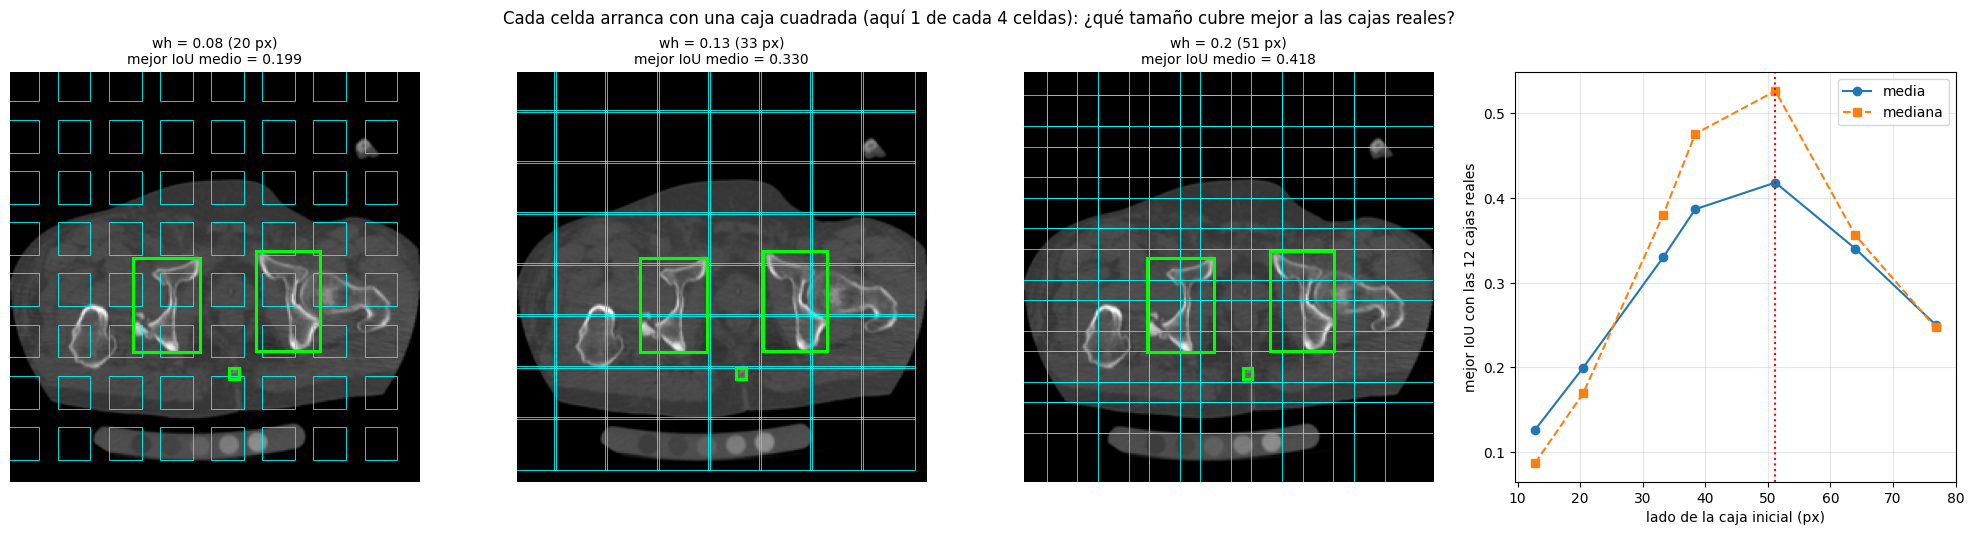

In [19]:
# ---- Prior de objectness: la fracción real de celdas positivas (sección 3) ----
OBJ_PRIOR = T["obj_t"].mean().item()

# ---- Prior de tamaño de caja: ¿qué tamaño inicial cubre mejor a las cajas reales? ----
todas = torch.cat([t_["boxes"] for t_ in targets]).float()              # las 12 cajas reales [12, 4]
filas_celda = torch.arange(GRID_S).view(-1, 1).expand(GRID_S, GRID_S).reshape(-1)
cols_celda = torch.arange(GRID_S).view(1, -1).expand(GRID_S, GRID_S).reshape(-1)

def cajas_iniciales(wh):
    """Una caja por celda: cuadrado de lado wh*256 centrado en la celda (tx = ty = 0.5)."""
    t0 = torch.tensor([[0.5, 0.5, wh, wh]]).expand(GRID_S * GRID_S, 4)
    return decode_boxes(filas_celda, cols_celda, t0)                    # [256, 4]

candidatos = [0.05, 0.08, 0.13, 0.15, 0.20, 0.25, 0.30]
resultados = []
print(f"{'wh':>5} {'lado (px)':>10} {'mejor IoU medio':>16} {'mediana':>9}")
for wh in candidatos:
    mejor = pairwise_iou(cajas_iniciales(wh), todas).max(dim=0).values  # mejor IoU de cada caja real entre las 256 iniciales
    resultados.append((wh, mejor.mean().item(), mejor.median().item()))
    print(f"{wh:>5.2f} {wh * IMG_SIZE:>10.1f} {resultados[-1][1]:>16.3f} {resultados[-1][2]:>9.3f}")
WH_PRIOR = max(resultados, key=lambda r: r[1])[0]
cobertura = {wh: m for wh, m, _ in resultados}
print(f"\nOBJ_PRIOR = {OBJ_PRIOR:.4f} (fracción real de celdas positivas) | WH_PRIOR = {WH_PRIOR} (mayor cobertura)")

# ---- Figura: cajas iniciales sobre una imagen real + curva de cobertura ----
k = 1
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
sel = ((filas_celda % 2 == 0) & (cols_celda % 2 == 0)).nonzero().flatten()      # 1 de cada 4 celdas, para no saturar el dibujo
for ax, wh in zip(axes[:3], (0.08, 0.13, WH_PRIOR)):
    ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
    cb = cajas_iniciales(wh)
    for idx in sel.tolist():
        dibujar_caja(ax, cb[idx], "cyan", lw=0.6)
    for b in targets[k]["boxes"]:
        dibujar_caja(ax, b, "lime", lw=2.2)
    ax.set_title(f"wh = {wh} ({wh * IMG_SIZE:.0f} px)\nmejor IoU medio = {cobertura[wh]:.3f}", fontsize=10)
    ax.axis("off")
ax = axes[3]
lados = [r[0] * IMG_SIZE for r in resultados]
ax.plot(lados, [r[1] for r in resultados], "o-", label="media")
ax.plot(lados, [r[2] for r in resultados], "s--", label="mediana")
ax.axvline(WH_PRIOR * IMG_SIZE, color="red", ls=":")
ax.set_xlabel("lado de la caja inicial (px)")
ax.set_ylabel("mejor IoU con las 12 cajas reales")
ax.legend()
ax.grid(alpha=0.3)
plt.suptitle("Cada celda arranca con una caja cuadrada (aquí 1 de cada 4 celdas): ¿qué tamaño cubre mejor a las cajas reales?", y=1.02)
plt.tight_layout()
plt.show()

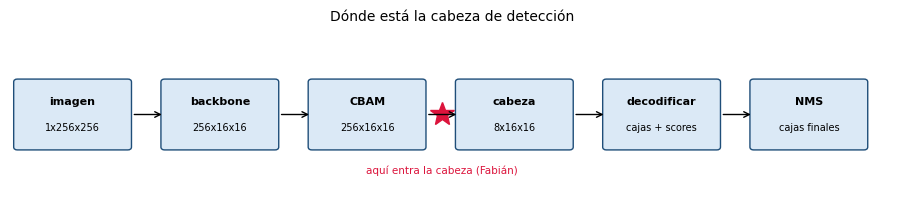

OK | 1. salida (6, 8, 16, 16) y todos los valores finitos
OK | 2. priors: P(objeto) = 0.0059 (objetivo 0.0078) | tw,th = 0.233 (objetivo 0.2) | tx,ty = 0.451 (objetivo 0.5)
OK | 3. canales en su sitio; obj (6, 16, 16), caja (6, 16, 16, 4), clase (6, 16, 16, 3) coinciden con obj_t, box_t, cls_t
OK | 4. parámetros de la cabeza = 296,200  (294,912 + 256 + 1,032)
OK | 5. gradiente finito en todos los parámetros y en el mapa de entrada (norma = 3.634e-03)


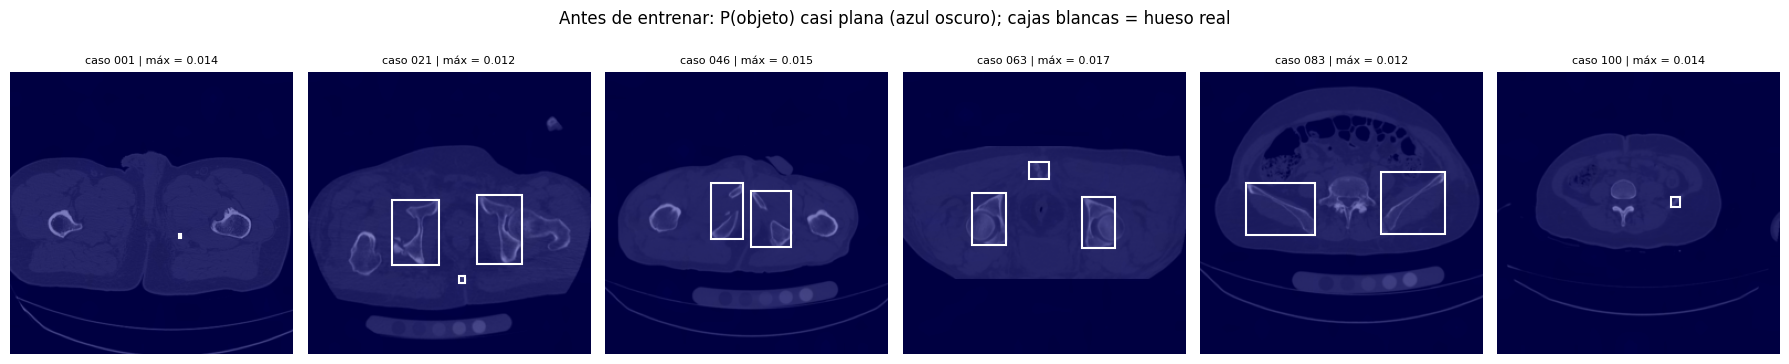

In [ ]:
import matplotlib.patches as patches

# ---- Diagrama (adaptado de la función `esquema` de S7_2) ----
def esquema(bloques, inserciones, titulo):
    """bloques: lista de (nombre, forma). inserciones: dict índice -> texto marcado con una estrella después de ese bloque."""
    fig, ax = plt.subplots(figsize=(1.9 * len(bloques), 2.3))
    ax.set_xlim(0, len(bloques) * 2)
    ax.set_ylim(0, 3)
    ax.axis("off")
    for i, (n, forma) in enumerate(bloques):
        ax.add_patch(patches.FancyBboxPatch((i * 2 + 0.1, 1.0), 1.5, 1.1, boxstyle="round,pad=0.05", fc="#dbe9f6", ec="#1f4e79"))
        ax.text(i * 2 + 0.85, 1.72, n, ha="center", fontsize=8, weight="bold")
        ax.text(i * 2 + 0.85, 1.28, forma, ha="center", fontsize=7)
        if i < len(bloques) - 1:
            ax.annotate("", (i * 2 + 2.1, 1.55), (i * 2 + 1.65, 1.55), arrowprops=dict(arrowstyle="->"))
        if i in inserciones:
            ax.plot(i * 2 + 1.87, 1.55, marker="*", ms=18, color="crimson")
            ax.text(i * 2 + 1.87, 0.55, inserciones[i], ha="center", fontsize=7.5, color="crimson")
    ax.set_title(titulo, fontsize=10)
    plt.show()

esquema([("imagen", "1x256x256"), ("backbone", "256x16x16"), ("CBAM", "256x16x16"),
         ("cabeza", "8x16x16"), ("decodificar", "cajas + scores"), ("NMS", "cajas finales")],
        {2: "aquí entra la cabeza"},
        "Dónde está la cabeza de detección")


# ---- La cabeza ----
class GridDetectionHead(nn.Module):
    """Entrada [B, C, S, S] -> logits crudos [B, 8, S, S].
    canal 0 = objectness | canales 1-4 = tx, ty, tw, th | canales 5-7 = clases."""
    def __init__(self, obj_prior, wh_prior, in_channels=256, hidden=128, num_classes=3):
        super().__init__()
        self.num_classes = num_classes
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1, bias=False),   # cada celda mira a sus vecinas
            nn.GroupNorm(8, hidden),                                               # no depende del batch: sin brecha train/eval
            nn.ReLU(inplace=True),
        )
        self.pred = nn.Conv2d(hidden, 1 + 4 + num_classes, kernel_size=1)
        with torch.no_grad():
            self.pred.bias.zero_()                                          # tx, ty -> sigmoide(0) = 0.5 (centro de la celda)
            self.pred.bias[CH_OBJ] = math.log(obj_prior / (1 - obj_prior))  # prior de objectness = fracción real de positivas
            self.pred.bias[3:5] = math.log(wh_prior / (1 - wh_prior))       # tw, th = tamaño inicial elegido por cobertura

    def forward(self, x):
        return self.pred(self.conv(x))


def split_head_output(out):
    """[B,8,S,S] -> obj_logit [B,S,S], box_logit [B,S,S,4], cls_logit [B,S,S,C] (mismo orden de celdas que build_targets)."""
    obj_logit = out[:, CH_OBJ]
    box_logit = out[:, CH_BOX].permute(0, 2, 3, 1)
    cls_logit = out[:, CH_CLS].permute(0, 2, 3, 1)
    return obj_logit, box_logit, cls_logit


# Features sintéticos fijos (uno por imagen) para que esta sección no dependa del backbone de Miguel ni del CBAM de Annie
torch.manual_seed(SEED)
FMAP = torch.randn(len(targets), 256, GRID_S, GRID_S)
head = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
fm = FMAP.to(DEVICE)
with torch.no_grad():
    out = head(fm)

# ---------------- Controles esenciales de la sección 4 ----------------
# 1) Forma y valores finitos
assert tuple(out.shape) == (6, 8, GRID_S, GRID_S) and bool(torch.isfinite(out).all()), f"FALLA: forma {tuple(out.shape)}"
print(f"OK | 1. salida {tuple(out.shape)} y todos los valores finitos")

# 2) Los sesgos iniciales dejan a la red en el punto de partida que elegimos
obj_logit, box_logit, cls_logit = split_head_output(out)
p_obj = torch.sigmoid(obj_logit).mean().item()
p_wh = torch.sigmoid(box_logit[..., 2:]).mean().item()
p_xy = torch.sigmoid(box_logit[..., :2]).mean().item()
assert OBJ_PRIOR / 4 < p_obj < OBJ_PRIOR * 6, f"FALLA: P(objeto) media = {p_obj:.4f}"
assert 0.6 * WH_PRIOR < p_wh < 1.5 * WH_PRIOR, f"FALLA: tw,th medios = {p_wh:.3f}"
assert 0.3 < p_xy < 0.7, f"FALLA: tx,ty medios = {p_xy:.3f}"
print(f"OK | 2. priors: P(objeto) = {p_obj:.4f} (objetivo {OBJ_PRIOR:.4f}) | tw,th = {p_wh:.3f} (objetivo {WH_PRIOR}) | tx,ty = {p_xy:.3f} (objetivo 0.5)")

# 3) Los canales están donde dijimos y las formas coinciden con los tensores objetivo de la sección 3
assert torch.equal(obj_logit, out[:, 0]) and torch.equal(box_logit[..., 2], out[:, 3]) and torch.equal(cls_logit[..., 1], out[:, 6]), "FALLA: canales"
assert obj_logit.shape == T["obj_t"].shape and box_logit.shape == T["box_t"].shape and cls_logit.shape[:-1] == T["cls_t"].shape, "FALLA: formas vs objetivos"
print(f"OK | 3. canales en su sitio; obj {tuple(obj_logit.shape)}, caja {tuple(box_logit.shape)}, clase {tuple(cls_logit.shape)} coinciden con obj_t, box_t, cls_t")

# 4) Número de parámetros: 256*128*9 (conv 3x3) + 2*128 (GroupNorm) + 128*8 + 8 (conv 1x1)
n_params = sum(p.numel() for p in head.parameters() if p.requires_grad)
assert n_params == 296_200, f"FALLA: {n_params:,} parámetros"
print(f"OK | 4. parámetros de la cabeza = {n_params:,}  (294,912 + 256 + 1,032)")

# 5) El gradiente llega a todos los parámetros de la cabeza y hasta el mapa de entrada (por donde vendrá el backbone)
head.zero_grad()
fm_g = FMAP.clone().to(DEVICE).requires_grad_(True)
head(fm_g).mean().backward()
sin_grad = [n for n, p in head.named_parameters() if p.grad is None or not torch.isfinite(p.grad).all()]
assert not sin_grad, f"FALLA: sin gradiente finito: {sin_grad}"
assert fm_g.grad is not None and fm_g.grad.abs().sum().item() > 0, "FALLA: el gradiente no llega al mapa de entrada"
print(f"OK | 5. gradiente finito en todos los parámetros y en el mapa de entrada (norma = {fm_g.grad.norm().item():.3e})")


# ---- Mapa de P(objeto) sobre la imagen (adaptado de `superponer` de S7_2) ----
def superponer(ax, img, mapa, titulo, cmap="jet", alpha=0.5, vmax=1.0):
    img = np.asarray(img)
    H, W = img.shape[:2]
    m = F.interpolate(mapa.detach().float().cpu()[None, None], size=(H, W), mode="bilinear", align_corners=False)[0, 0]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.imshow(m, cmap=cmap, alpha=alpha, vmin=0, vmax=vmax)
    ax.set_title(titulo, fontsize=8)
    ax.axis("off")

prob = torch.sigmoid(out[:, CH_OBJ]).detach().cpu()
fig, axes = plt.subplots(1, 6, figsize=(18, 3.6))
for k, ax in enumerate(axes):
    superponer(ax, imgs[k, 0], prob[k], f"caso {targets[k]['case_id']} | máx = {prob[k].max():.3f}")
    for b in targets[k]["boxes"]:
        dibujar_caja(ax, b, "white", lw=1.5)
plt.suptitle("Antes de entrenar: P(objeto) casi plana (azul oscuro); cajas blancas = hueso real", y=1.02)
plt.tight_layout()
plt.show()

## 5. Las pérdidas: qué mide cada una y por qué

La cabeza hace tres cosas a la vez, y cada una necesita su propio error:

| Término | Pregunta | Qué se calcula | Dónde |
|---|---|---|---|
| **obj** | ¿hay un hueso con su centro aquí? | BCE con logits | **todas** las celdas |
| **box** | ¿dónde está su caja? | L1 sobre `tx, ty, tw, th` **+** (1 − IoU) | solo celdas con hueso |
| **cls** | ¿qué hueso es? | entropía cruzada sobre 3 clases | solo celdas con hueso |

**La regla clave.** En una celda vacía no hay caja ni clase que aprender, así que el fondo se ignora en `box` y `cls`. Pero `obj` sí mira todas las celdas: si no, la red nunca aprendería a decir "aquí no hay nada".

**Decisiones de diseño.**
1. **obj: positivos y negativos se promedian por separado.** Hay ~1 celda con hueso por cada 128 de fondo. Si se promediara todo junto, el fondo ahogaría la señal de los positivos. El peso `noobj` regula cuánto cuentan los negativos.
2. **box: L1 más (1 − IoU).** La **L1** mantiene un gradiente constante aunque el error sea pequeño (el detector del profesor en S7_2 también usa L1). El **IoU** no depende de la escala: un error en una caja de 2 px pesa lo mismo que en una de 60 px, y es la métrica del proyecto. Por sí solo no basta, porque si las cajas no se tocan su gradiente es cero, y ahí la L1 sigue empujando.
3. **cls:** entropía cruzada sobre logits crudos, sin activación previa (el softmax va dentro de la pérdida).
4. **Normalización:** las tres se dividen entre el número de celdas con hueso, con un mínimo de 1 para que un batch sin cajas no dé 0/0 = NaN.
5. **float32:** la pérdida se calcula siempre en `float32`, compatible con AMP (igual que en el detector del profesor).

**Los pesos λ.** Se dejan en 1.0 y se calibran en la sección 6, comparando entrenamientos. Aquí solo medimos las magnitudes iniciales.

**Preguntas que el profesor podría hacer.**
- *¿Qué pasa con λ = 1000 en la caja?* El gradiente de la caja domina y la clasificación casi no aprende.
- *¿Por qué la caja usa sigmoide y la clase no?* La sigmoide acota las coordenadas a [0, 1]. La entropía cruzada ya aplica el softmax por dentro y espera logits crudos.

In [20]:
LAMBDAS = {"obj": 1.0, "box": 1.0, "cls": 1.0,   # peso de cada una de las 3 pérdidas (se calibran en la sección 6)
           "noobj": 1.0,                          # peso de los negativos dentro de la pérdida de objectness
           "l1": 1.0, "iou": 1.0}                 # peso de cada parte de la pérdida de caja


def grid_detection_loss(out, tgt, lambdas=LAMBDAS):
    """out: logits crudos [B,8,S,S]. tgt: dict de build_targets.
    Devuelve un dict de tensores: total, obj, obj_pos, obj_neg, box, box_l1, box_iou, cls, mean_iou, n_pos.
    Regla clave: objectness se evalúa en TODAS las celdas; caja y clase solo en las celdas con objeto."""
    out = out.float()                                    # la pérdida siempre en float32 (compatible con AMP)
    obj_logit, box_logit, cls_logit = split_head_output(out)
    obj_t = tgt["obj_t"].to(out.device)
    box_t = tgt["box_t"].to(out.device)
    cls_t = tgt["cls_t"].to(out.device)

    pos = obj_t > 0.5                                    # [B,S,S] celdas con objeto
    n_pos = pos.sum().clamp(min=1).float()               # clamp: sin cajas no se divide entre 0
    n_neg = (~pos).sum().clamp(min=1).float()

    # 1) Objectness: TODAS las celdas; positivos y negativos se promedian por separado
    bce = F.binary_cross_entropy_with_logits(obj_logit, obj_t, reduction="none")
    obj_pos = bce[pos].sum() / n_pos
    obj_neg = bce[~pos].sum() / n_neg
    obj = obj_pos + lambdas["noobj"] * obj_neg

    # 2) Caja y 3) clase: SOLO celdas positivas
    b, r, c = pos.nonzero(as_tuple=True)
    t_pred = torch.sigmoid(box_logit[b, r, c])           # [N,4] tx,ty,tw,th predichos
    t_gt = box_t[b, r, c]                                # [N,4] los de la caja real
    box_l1 = (t_pred - t_gt).abs().sum() / (4 * n_pos)
    iou = box_iou(decode_boxes(r, c, t_pred), decode_boxes(r, c, t_gt))   # [N] IoU en píxeles
    box_iou_loss = (1 - iou).sum() / n_pos
    box = lambdas["l1"] * box_l1 + lambdas["iou"] * box_iou_loss

    if b.numel() == 0:
        cls = cls_logit.sum() * 0.0                      # sin positivas: 0, pero conectado al grafo
    else:
        cls = F.cross_entropy(cls_logit[b, r, c], cls_t[b, r, c], reduction="sum") / n_pos

    total = lambdas["obj"] * obj + lambdas["box"] * box + lambdas["cls"] * cls
    mean_iou = iou.detach().mean() if iou.numel() > 0 else torch.zeros((), device=out.device)
    return {"total": total, "obj": obj, "obj_pos": obj_pos, "obj_neg": obj_neg,
            "box": box, "box_l1": box_l1, "box_iou": box_iou_loss,
            "cls": cls, "mean_iou": mean_iou, "n_pos": pos.sum()}


def logits_perfectos(Tg):
    """Logits que reproducen los objetivos casi exactamente (para comprobar que la pérdida llega a ~0)."""
    obj_t, box_t, cls_t = Tg["obj_t"], Tg["box_t"], Tg["cls_t"]
    B_, S_ = obj_t.shape[0], obj_t.shape[1]
    pos = obj_t > 0.5
    o = torch.zeros(B_, 8, S_, S_)
    o[:, CH_OBJ] = pos.float() * 40 - 20                 # +20 donde hay objeto, -20 en el fondo
    tt = box_t.clamp(1e-4, 1 - 1e-4)
    o[:, CH_BOX] = torch.log(tt / (1 - tt)).permute(0, 3, 1, 2)       # inversa de la sigmoide
    b, r, c = pos.nonzero(as_tuple=True)
    o[b, 5 + cls_t[b, r, c], r, c] = 20.0                # clase correcta con logit alto
    return o.to(DEVICE)


# ---------------- Controles esenciales de la sección 5 ----------------
LOSS = grid_detection_loss
pos5 = (T["obj_t"] > 0.5)
bb, rr, cc = pos5.nonzero(as_tuple=True)
out_real = head(fm)                                      # salida de la cabeza de la sección 4 (con gradiente)

# 1) Finita con el batch real y los lambda se aplican
L = LOSS(out_real, T)
vals = {k: L[k].item() for k in ("total", "obj", "box", "cls")}
assert all(math.isfinite(v) for v in vals.values()), f"FALLA: {vals}"
assert abs(vals["total"] - (vals["obj"] + vals["box"] + vals["cls"])) < 1e-4, "FALLA: total != obj + box + cls"
lam2 = {"obj": 2.0, "box": 3.0, "cls": 5.0, "noobj": 1.0, "l1": 1.0, "iou": 1.0}
L2 = LOSS(out_real, T, lam2)
assert abs(L2["total"].item() - (2 * L2["obj"].item() + 3 * L2["box"].item() + 5 * L2["cls"].item())) < 1e-4, "FALLA: los lambda no se aplican"
print(f"OK | 1. finitas: total={vals['total']:.3f} obj={vals['obj']:.3f} box={vals['box']:.3f} cls={vals['cls']:.3f}; total = suma ponderada")

# 2) Predicciones perfectas -> pérdida ~ 0 e IoU ~ 1
Lp = LOSS(logits_perfectos(T), T)
assert Lp["total"].item() < 1e-2 and Lp["mean_iou"].item() > 0.99, f"FALLA: total={Lp['total'].item():.2e}, IoU={Lp['mean_iou'].item():.4f}"
print(f"OK | 2. logits perfectos: total = {Lp['total'].item():.2e}, IoU medio = {Lp['mean_iou'].item():.4f}")

# 3) REGLA CLAVE: el fondo se ignora en caja y clase, pero NO en objectness
out_a = logits_perfectos(T)
out_b = out_a.clone()
fondo = (~pos5).unsqueeze(1).expand(-1, 7, -1, -1).to(DEVICE)             # canales 1..7 en celdas de fondo
torch.manual_seed(SEED)
out_b[:, 1:] = torch.where(fondo, torch.randn_like(out_b[:, 1:]) * 10, out_b[:, 1:])
La, Lb = LOSS(out_a, T), LOSS(out_b, T)
assert all(torch.allclose(La[k], Lb[k], atol=1e-6) for k in ("box", "box_l1", "box_iou", "cls")), "FALLA: el fondo contamina caja o clase"
out_c = out_a.clone()
out_c[:, CH_OBJ] = torch.where(pos5.to(DEVICE), out_c[:, CH_OBJ], torch.full_like(out_c[:, CH_OBJ], 5.0))
Lc = LOSS(out_c, T)
assert Lc["obj_neg"].item() > 4.0, "FALLA: objectness no mira el fondo"
print(f"OK | 3. basura en caja y clase del FONDO no cambia la pérdida; falsos positivos de objectness sí (obj_neg = {Lc['obj_neg'].item():.2f})")

# 4) En las celdas con hueso, equivocarse SÍ cuesta
out_d = out_a.clone()
out_d[bb, 5 + (T["cls_t"][bb, rr, cc] + 1) % 3, rr, cc] = 30.0            # clase equivocada con logit alto
out_e = out_a.clone()
out_e[bb, 3, rr, cc] = -5.0
out_e[bb, 4, rr, cc] = -5.0                                              # cajas diminutas
Ld, Le = LOSS(out_d, T), LOSS(out_e, T)
assert Ld["cls"].item() > 5.0 and Le["box_iou"].item() > 0.5, f"FALLA: cls={Ld['cls'].item():.2f}, box_iou={Le['box_iou'].item():.3f}"
print(f"OK | 4. clase equivocada: cls = {Ld['cls'].item():.2f} | cajas diminutas: box_iou = {Le['box_iou'].item():.3f}")

# 5) Estabilidad: logits extremos, float16 y batch sin cajas
Lx = LOSS(torch.randn(len(targets), 8, GRID_S, GRID_S) * 1e3, T)
Lh = LOSS(torch.randn(len(targets), 8, GRID_S, GRID_S).half(), T)
T_vacio = build_targets([{"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.long)}])
out_v = torch.randn(1, 8, GRID_S, GRID_S, requires_grad=True)
Lv = LOSS(out_v, T_vacio)
Lv["total"].backward()
assert all(torch.isfinite(v).all().item() for v in Lx.values()), "FALLA: logits extremos"
assert all(torch.isfinite(v).all().item() for v in Lh.values()), "FALLA: float16"
assert Lv["box"].item() == 0.0 and Lv["cls"].item() == 0.0 and bool(torch.isfinite(out_v.grad).all()), "FALLA: batch sin cajas"
print(f"OK | 5. sin NaN con logits de ±1000, float16 y batch sin cajas (box = cls = 0, total = {Lv['total'].item():.3f}, backward finito)")

# 6) Cada pérdida entrena SOLO su parte de la salida (se ve en el gradiente del sesgo de la capa final)
def grad_bias(term):
    torch.manual_seed(SEED)
    d = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
    LOSS(d(fm), T)[term].backward()
    return d.pred.bias.grad.clone()

g_obj, g_box, g_cls = grad_bias("obj"), grad_bias("box"), grad_bias("cls")
assert g_obj[0].abs().item() > 0 and g_obj[1:].abs().max().item() == 0.0, "FALLA: obj no solo en el canal 0"
assert bool((g_box[1:5].abs() > 0).all()) and g_box[0].abs().item() == 0.0 and g_box[5:].abs().max().item() == 0.0, "FALLA: box no solo en 1-4"
assert g_cls[5:].abs().sum().item() > 0 and g_cls[:5].abs().max().item() == 0.0, "FALLA: cls no solo en 5-7"
print("OK | 6. obj entrena solo el canal 0, box solo los canales 1-4 y cls solo los canales 5-7")

OK | 1. finitas: total=7.129 obj=5.141 box=0.820 cls=1.168; total = suma ponderada
OK | 2. logits perfectos: total = 1.36e-08, IoU medio = 1.0000
OK | 3. basura en caja y clase del FONDO no cambia la pérdida; falsos positivos de objectness sí (obj_neg = 5.01)
OK | 4. clase equivocada: cls = 10.00 | cajas diminutas: box_iou = 0.958
OK | 5. sin NaN con logits de ±1000, float16 y batch sin cajas (box = cls = 0, total = 0.859, backward finito)
OK | 6. obj entrena solo el canal 0, box solo los canales 1-4 y cls solo los canales 5-7


--- Desglose al inicializar (cabeza de la sección 4, features sintéticos, todos los lambda = 1) ---
  obj_pos  5.1352
  obj_neg  0.0060
  box_l1   0.1857
  box_iou  0.6342
  cls      1.1683
  IoU medio inicial de la caja predicha en las celdas con hueso: 0.366

--- Equilibrio de magnitudes: lambda_k = media / L_k (punto de partida, no valor final) ---
  obj  L_inicial = 5.141   lambda sugerido = 0.46
  box  L_inicial = 0.820   lambda sugerido = 2.90
  cls  L_inicial = 1.168   lambda sugerido = 2.03


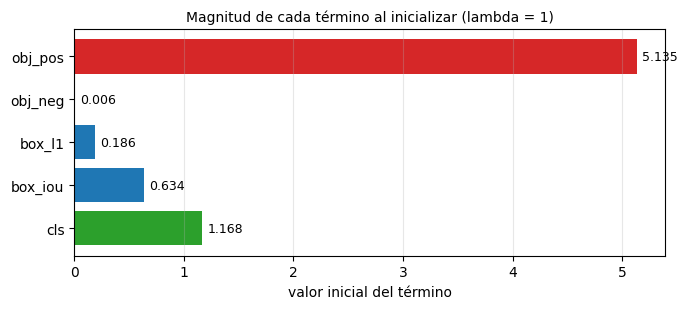

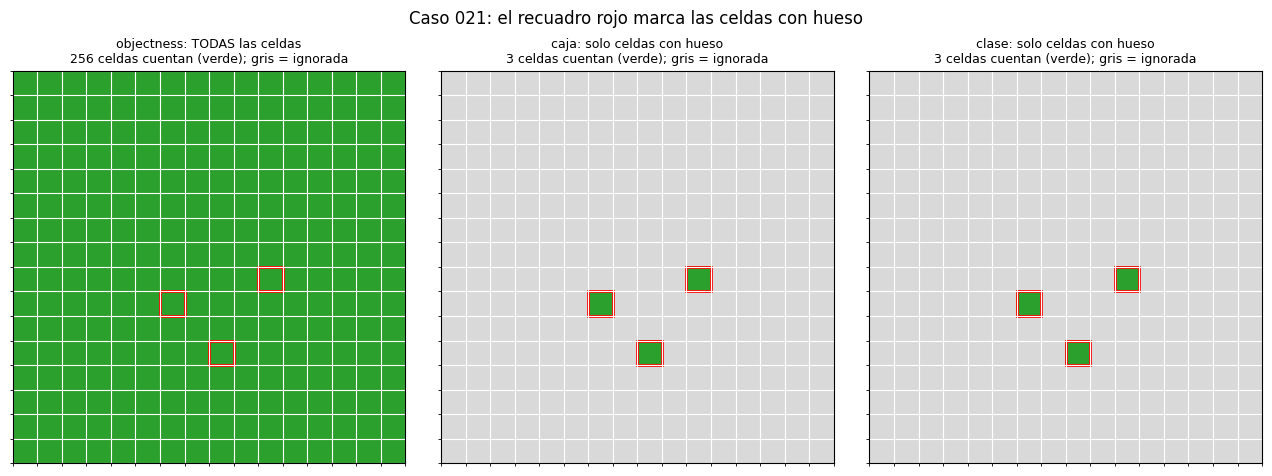

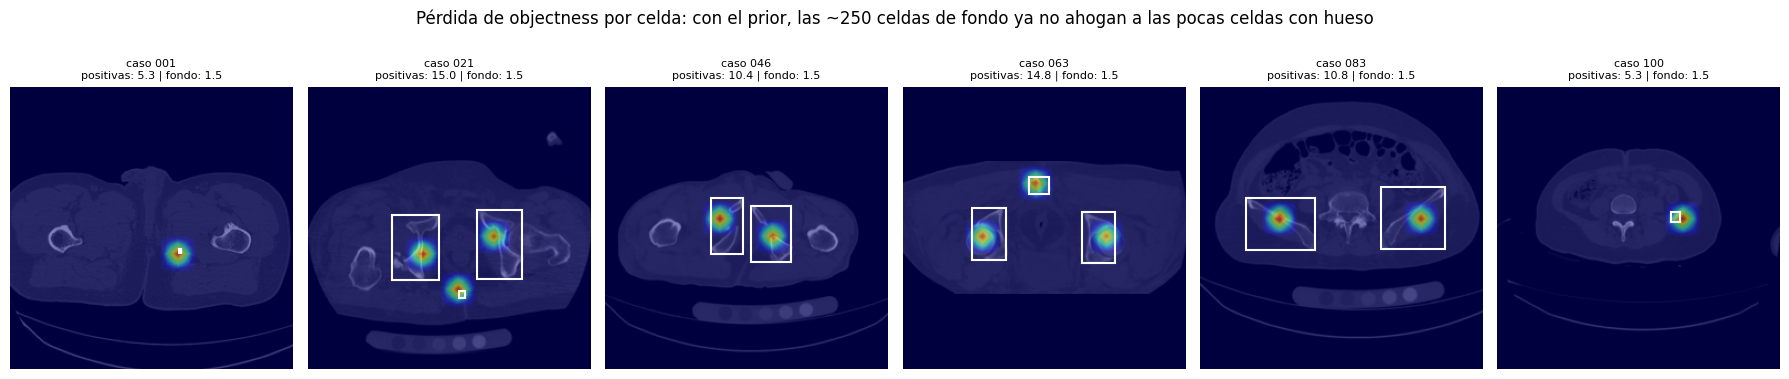

Sin prior (P = 0.5 en todas las celdas) cada celda costaría ln 2 = 0.693: el fondo sumaría ~176 por imagen, contra ~1.4 de las celdas con hueso.


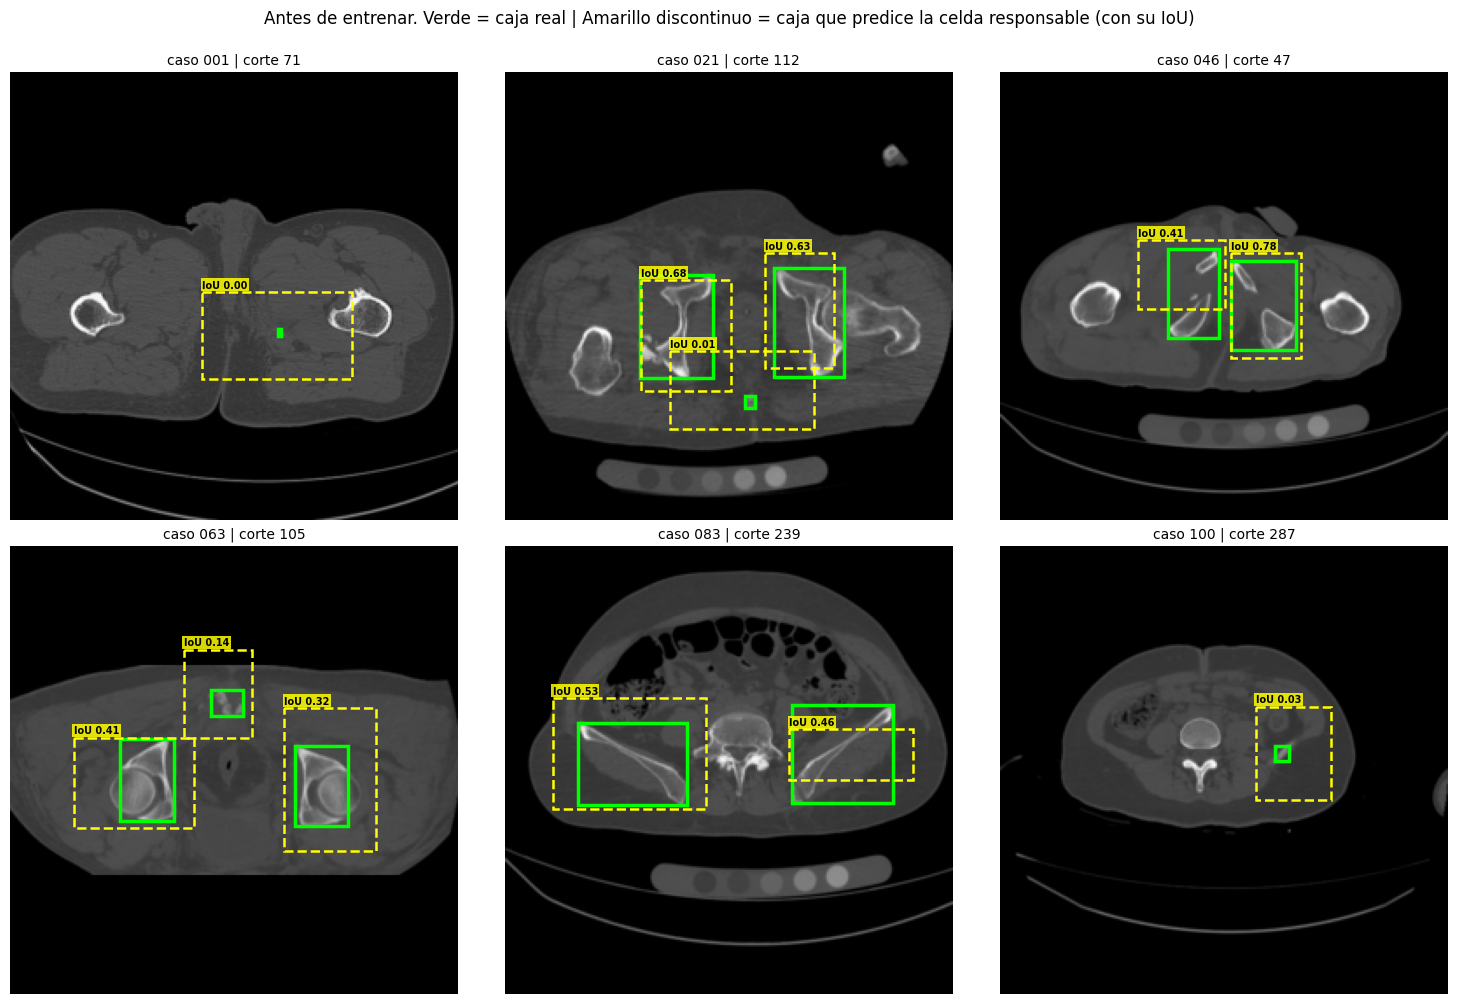

In [21]:
# ---- Magnitudes al inicializar (el equivalente al ejemplo numérico del profesor sobre por qué hay que ponderar) ----
with torch.no_grad():
    Li = LOSS(head(fm), T)
terminos = ["obj_pos", "obj_neg", "box_l1", "box_iou", "cls"]
valores = [Li[k].item() for k in terminos]
print("--- Desglose al inicializar (cabeza de la sección 4, features sintéticos, todos los lambda = 1) ---")
for k, v in zip(terminos, valores):
    print(f"  {k:<8} {v:.4f}")
print(f"  IoU medio inicial de la caja predicha en las celdas con hueso: {Li['mean_iou'].item():.3f}")

mags = {"obj": Li["obj"].item(), "box": Li["box"].item(), "cls": Li["cls"].item()}
media = sum(mags.values()) / 3
print("\n--- Equilibrio de magnitudes: lambda_k = media / L_k (punto de partida, no valor final) ---")
for k, m in mags.items():
    print(f"  {k:<4} L_inicial = {m:.3f}   lambda sugerido = {media / m:.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
colores = ["#d62728", "#d62728", "#1f77b4", "#1f77b4", "#2ca02c"]
ax.barh(terminos[::-1], valores[::-1], color=colores[::-1])
for i, v in enumerate(valores[::-1]):
    ax.text(v + 0.05, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("valor inicial del término")
ax.set_title("Magnitud de cada término al inicializar (lambda = 1)", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Figura A: qué celdas cuenta cada pérdida (imagen 1) ----
from matplotlib.colors import ListedColormap
k = 1
pos_k = (T["obj_t"][k] > 0.5).numpy()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
paneles = [("objectness: TODAS las celdas", np.ones_like(pos_k)),
           ("caja: solo celdas con hueso", pos_k),
           ("clase: solo celdas con hueso", pos_k)]
for ax, (titulo, contada) in zip(axes, paneles):
    ax.imshow(contada, cmap=ListedColormap(["#d9d9d9", "#2ca02c"]), vmin=0, vmax=1)
    for i, j in np.argwhere(pos_k):
        ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec="red", lw=2))
    ax.set_xticks(np.arange(-0.5, GRID_S, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_S, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{titulo}\n{int(contada.sum())} celdas cuentan (verde); gris = ignorada", fontsize=9)
plt.suptitle(f"Caso {targets[k]['case_id']}: el recuadro rojo marca las celdas con hueso", y=1.02)
plt.tight_layout()
plt.show()

# ---- Figura B: dónde se concentra la pérdida de objectness (por celda, sobre la imagen) ----
with torch.no_grad():
    bce_celda = F.binary_cross_entropy_with_logits(head(fm)[:, CH_OBJ].float(), T["obj_t"].to(DEVICE), reduction="none").cpu()
fig, axes = plt.subplots(1, 6, figsize=(18, 3.8))
vmax = float(bce_celda.max())
for k, ax in enumerate(axes):
    posk = T["obj_t"][k] > 0.5
    superponer(ax, imgs[k, 0], bce_celda[k], f"caso {targets[k]['case_id']}\npositivas: {bce_celda[k][posk].sum():.1f} | fondo: {bce_celda[k][~posk].sum():.1f}", vmax=vmax)
    for b in targets[k]["boxes"]:
        dibujar_caja(ax, b, "white", lw=1.5)
plt.suptitle("Pérdida de objectness por celda: con el prior, las ~250 celdas de fondo ya no ahogan a las pocas celdas con hueso", y=1.03)
plt.tight_layout()
plt.show()
n_neg_k = int((T["obj_t"] < 0.5).sum())
print(f"Sin prior (P = 0.5 en todas las celdas) cada celda costaría ln 2 = 0.693: el fondo sumaría ~{0.693 * n_neg_k / len(targets):.0f} por imagen, contra ~{0.693 * 12 / len(targets):.1f} de las celdas con hueso.")

# ---- Figura C: caja real (verde) vs caja predicha por la celda responsable (amarillo), ANTES de entrenar ----
@torch.no_grad()
def dibujar_pred_vs_gt(out, Tg, titulo):
    _, box_logit_, _ = split_head_output(out.float().cpu())
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for k, ax in zip(range(len(targets)), axes.ravel()):
        ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
        for i, j in Tg["obj_t"][k].nonzero().tolist():
            ri, ci = torch.tensor([i]), torch.tensor([j])
            b_pred = decode_boxes(ri, ci, torch.sigmoid(box_logit_[k, i, j])[None])
            b_gt = decode_boxes(ri, ci, Tg["box_t"][k, i, j][None])
            dibujar_caja(ax, b_gt[0], "lime", lw=2.5)
            dibujar_caja(ax, b_pred[0], "yellow", lw=1.8, ls="--", texto=f"IoU {box_iou(b_pred, b_gt).item():.2f}")
        ax.set_title(f"caso {targets[k]['case_id']} | corte {targets[k]['slice_index']}", fontsize=10)
        ax.axis("off")
    plt.suptitle(titulo, y=1.0)
    plt.tight_layout()
    plt.show()

dibujar_pred_vs_gt(head(fm), T, "Antes de entrenar. Verde = caja real | Amarillo discontinuo = caja que predice la celda responsable (con su IoU)")

## 6. Mini-overfit: ¿la cabeza y la pérdida pueden aprender?

**Qué hacemos.** Entrenamos solo la cabeza para memorizar los 12 objetivos del batch fijo, con los features sintéticos de la sección 4 (uno distinto por imagen).

**Qué demuestra y qué no.**
- Si la cabeza no puede memorizar 6 imágenes, hay un error en los objetivos, en la cabeza o en la pérdida. Si puede, esas tres piezas son coherentes entre sí.
- **No** demuestra que el modelo generalice. La prueba con el backbone real es el overfit de Hoyos.

**Qué comparamos.** Cuatro configuraciones de los pesos λ, con los mismos pesos iniciales y los mismos pasos:

| Config | Idea |
|---|---|
| A | todo en 1.0 (punto neutro) |
| B | λ sugeridos por equilibrio de magnitudes (sección 5) |
| C | caja ×5, como el detector del profesor en S7_2 |
| D | sin el término IoU (solo L1): ablación para justificar que el IoU aporta |

**Cómo comparar.** Los términos se miden **sin ponderar** por λ, porque el total no es comparable entre configuraciones con pesos distintos. Los criterios son el IoU final, la velocidad de convergencia (pasos hasta IoU ≥ 0.8) y que ningún término se estanque.

**Cómo decidir.** Se prefiere la configuración que converge más rápido sin empeorar `obj` ni `cls`. Es un resultado de una cabeza sola; los λ definitivos se revisan con el modelo completo.

A: todo en 1.0                 obj=1.00 box=1.00 cls=1.00 | l1=1.0 iou=1.0
B: equilibrio de magnitudes    obj=0.46 box=2.90 cls=2.03 | l1=1.0 iou=1.0
C: caja x5 (estilo S7_2)       obj=1.00 box=5.00 cls=1.00 | l1=1.0 iou=1.0
D: sin término IoU (solo L1)   obj=1.00 box=1.00 cls=1.00 | l1=1.0 iou=0.0

A: todo en 1.0                   6.6 s | IoU medio: 0.307 -> 0.832
B: equilibrio de magnitudes      6.5 s | IoU medio: 0.307 -> 0.861
C: caja x5 (estilo S7_2)         7.9 s | IoU medio: 0.307 -> 0.863
D: sin término IoU (solo L1)     8.5 s | IoU medio: 0.307 -> 0.823

OK | 1. en las 4 configuraciones: sin NaN, la pérdida total baja a menos de la mitad y el IoU medio sube más de 0.2

configuración                      obj     cls   box_l1   1-IoU  IoU final  IoU paso 100  pasos hasta IoU>=0.8
A: todo en 1.0                  0.0033  0.0002   0.0213  0.1685      0.832         0.656                   207
B: equilibrio de magnitudes     0.0102  0.0002   0.0180  0.1392      0.861         0.652   

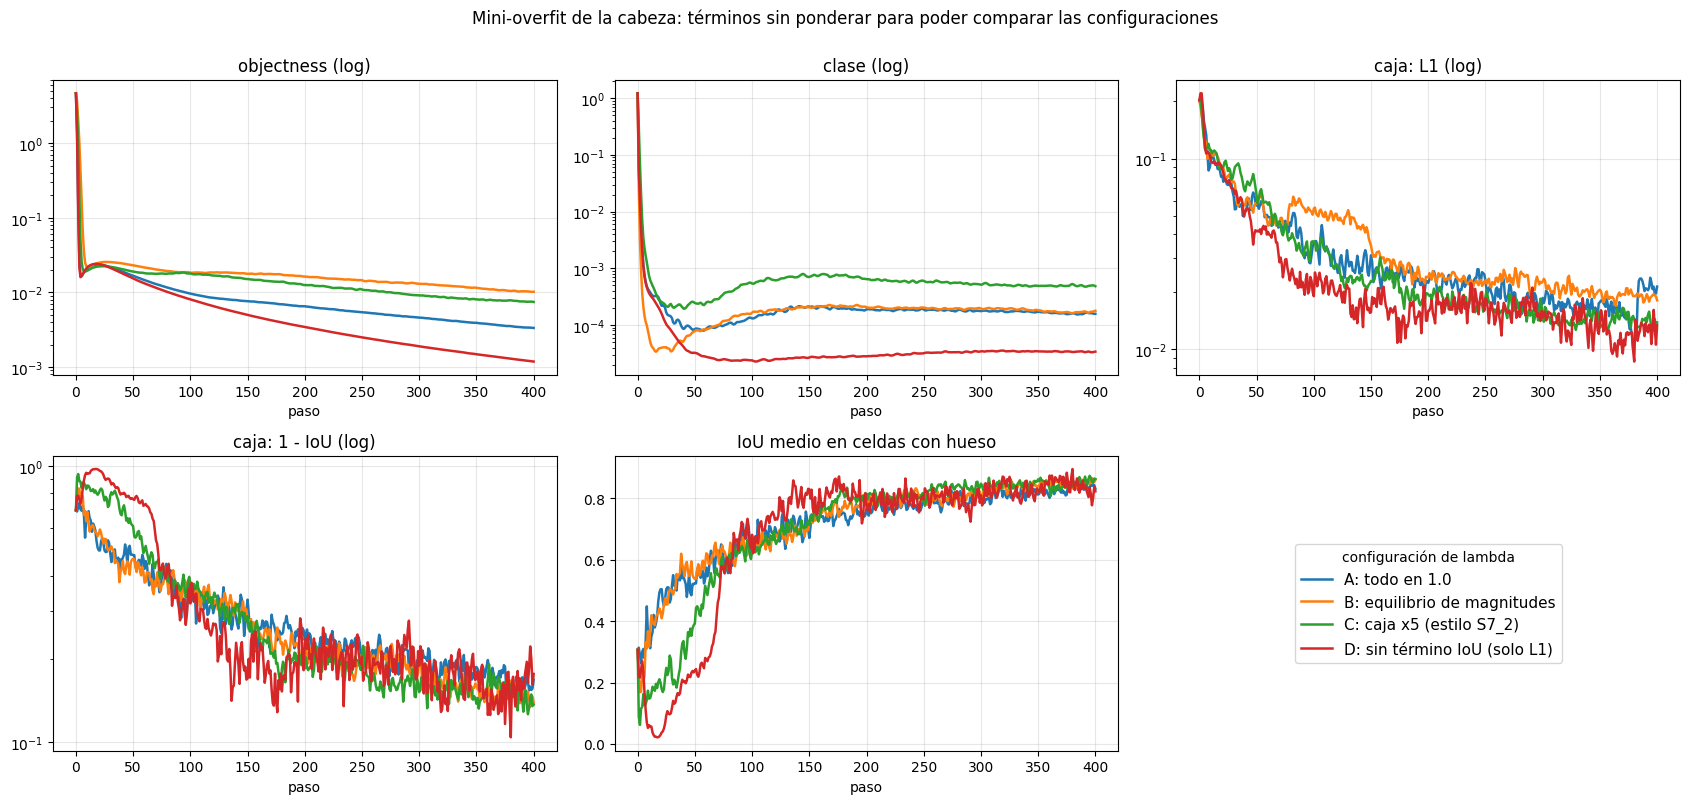

In [22]:
import time

def entrenar_cabeza(lambdas, pasos=400, lr=2e-3, semilla=SEED):
    """Entrena SOLO la cabeza sobre los features fijos `fm` para memorizar los objetivos T.
    Devuelve (cabeza, historial, segundos). El historial guarda los términos SIN ponderar por lambda (comparables entre configuraciones)."""
    torch.manual_seed(semilla)                                   # mismos pesos iniciales en todas las configuraciones
    h = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
    opt = torch.optim.AdamW(h.parameters(), lr=lr, weight_decay=0.0)
    hist = {k: [] for k in ("total", "obj", "box_l1", "box_iou", "cls", "mean_iou")}
    t0 = time.perf_counter()
    for paso in range(pasos + 1):
        L = LOSS(h(fm), T, lambdas)
        for k in hist:
            hist[k].append(L[k].item())
        if paso == pasos:
            break
        opt.zero_grad()
        L["total"].backward()
        opt.step()
    return h, hist, time.perf_counter() - t0


CONFIGS = {
    "A: todo en 1.0": dict(LAMBDAS),
    "B: equilibrio de magnitudes": {**LAMBDAS, **{k: media / m for k, m in mags.items()}},   # los lambda sugeridos de la sección 5
    "C: caja x5 (estilo S7_2)": {**LAMBDAS, "box": 5.0},
    "D: sin término IoU (solo L1)": {**LAMBDAS, "iou": 0.0},
}
for nombre, lam in CONFIGS.items():
    print(f"{nombre:<30} obj={lam['obj']:.2f} box={lam['box']:.2f} cls={lam['cls']:.2f} | l1={lam['l1']:.1f} iou={lam['iou']:.1f}")

print()
entrenados = {}
for nombre, lam in CONFIGS.items():
    h, hist, seg = entrenar_cabeza(lam)
    entrenados[nombre] = (h, hist, lam)
    print(f"{nombre:<30} {seg:5.1f} s | IoU medio: {hist['mean_iou'][0]:.3f} -> {hist['mean_iou'][-1]:.3f}")

# ---------------- Controles esenciales de la sección 6 ----------------
for nombre, (h, hist, lam) in entrenados.items():
    todo = [v for serie in hist.values() for v in serie]
    assert all(math.isfinite(v) for v in todo), f"FALLA: valores no finitos en {nombre}"
    assert hist["total"][-1] < 0.5 * hist["total"][0], f"FALLA: la pérdida no bajó a la mitad en {nombre}"
    assert hist["mean_iou"][-1] > hist["mean_iou"][0] + 0.2, f"FALLA: el IoU no mejoró en {nombre}"
print("\nOK | 1. en las 4 configuraciones: sin NaN, la pérdida total baja a menos de la mitad y el IoU medio sube más de 0.2")

# ---------------- Comparación (términos sin ponderar) ----------------
print(f"\n{'configuración':<30} {'obj':>7} {'cls':>7} {'box_l1':>8} {'1-IoU':>7} {'IoU final':>10} {'IoU paso 100':>13} {'pasos hasta IoU>=0.8':>21}")
for nombre, (h, hist, lam) in entrenados.items():
    hasta = next((i for i, v in enumerate(hist["mean_iou"]) if v >= 0.8), None)
    print(f"{nombre:<30} {hist['obj'][-1]:>7.4f} {hist['cls'][-1]:>7.4f} {hist['box_l1'][-1]:>8.4f} {hist['box_iou'][-1]:>7.4f} "
          f"{hist['mean_iou'][-1]:>10.3f} {hist['mean_iou'][100]:>13.3f} {('—' if hasta is None else hasta):>21}")

# ---------------- Curvas ----------------
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
paneles = [("obj", "objectness (log)", True), ("cls", "clase (log)", True), ("box_l1", "caja: L1 (log)", True),
           ("box_iou", "caja: 1 - IoU (log)", True), ("mean_iou", "IoU medio en celdas con hueso", False)]
for ax, (clave, titulo, log) in zip(axes.ravel(), paneles):
    for nombre, (h, hist, lam) in entrenados.items():
        ax.plot(hist[clave], label=nombre, lw=1.8)
    if log:
        ax.set_yscale("log")
    ax.set_title(titulo)
    ax.set_xlabel("paso")
    ax.grid(alpha=0.3)
handles, etiquetas = axes[0, 0].get_legend_handles_labels()
axes[1, 2].axis("off")
axes[1, 2].legend(handles, etiquetas, loc="center", fontsize=11, title="configuración de lambda")
plt.suptitle("Mini-overfit de la cabeza: términos sin ponderar para poder comparar las configuraciones", y=1.0)
plt.tight_layout()
plt.show()

Mayor IoU final: C: caja x5 (estilo S7_2) (0.863). Revisa también la tabla: la velocidad de convergencia y los demás términos cuentan.
Celdas con P(objeto) > 0.5: 12 de 12 con hueso detectadas | falsos positivos: 0 | no detectadas: 0
Exactitud de clase en las celdas con hueso: 1.000


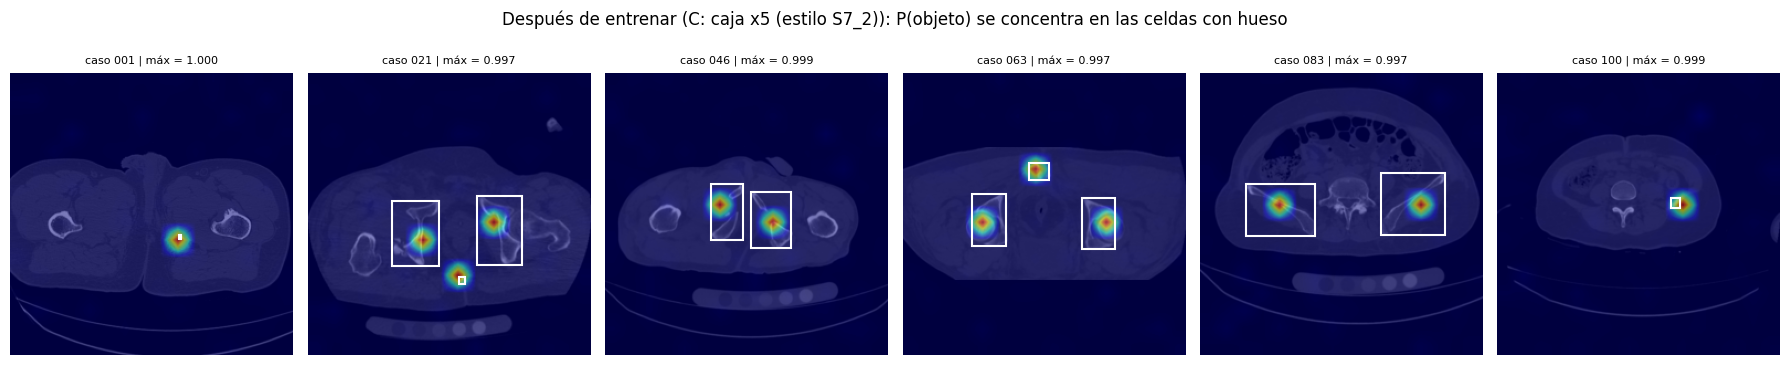

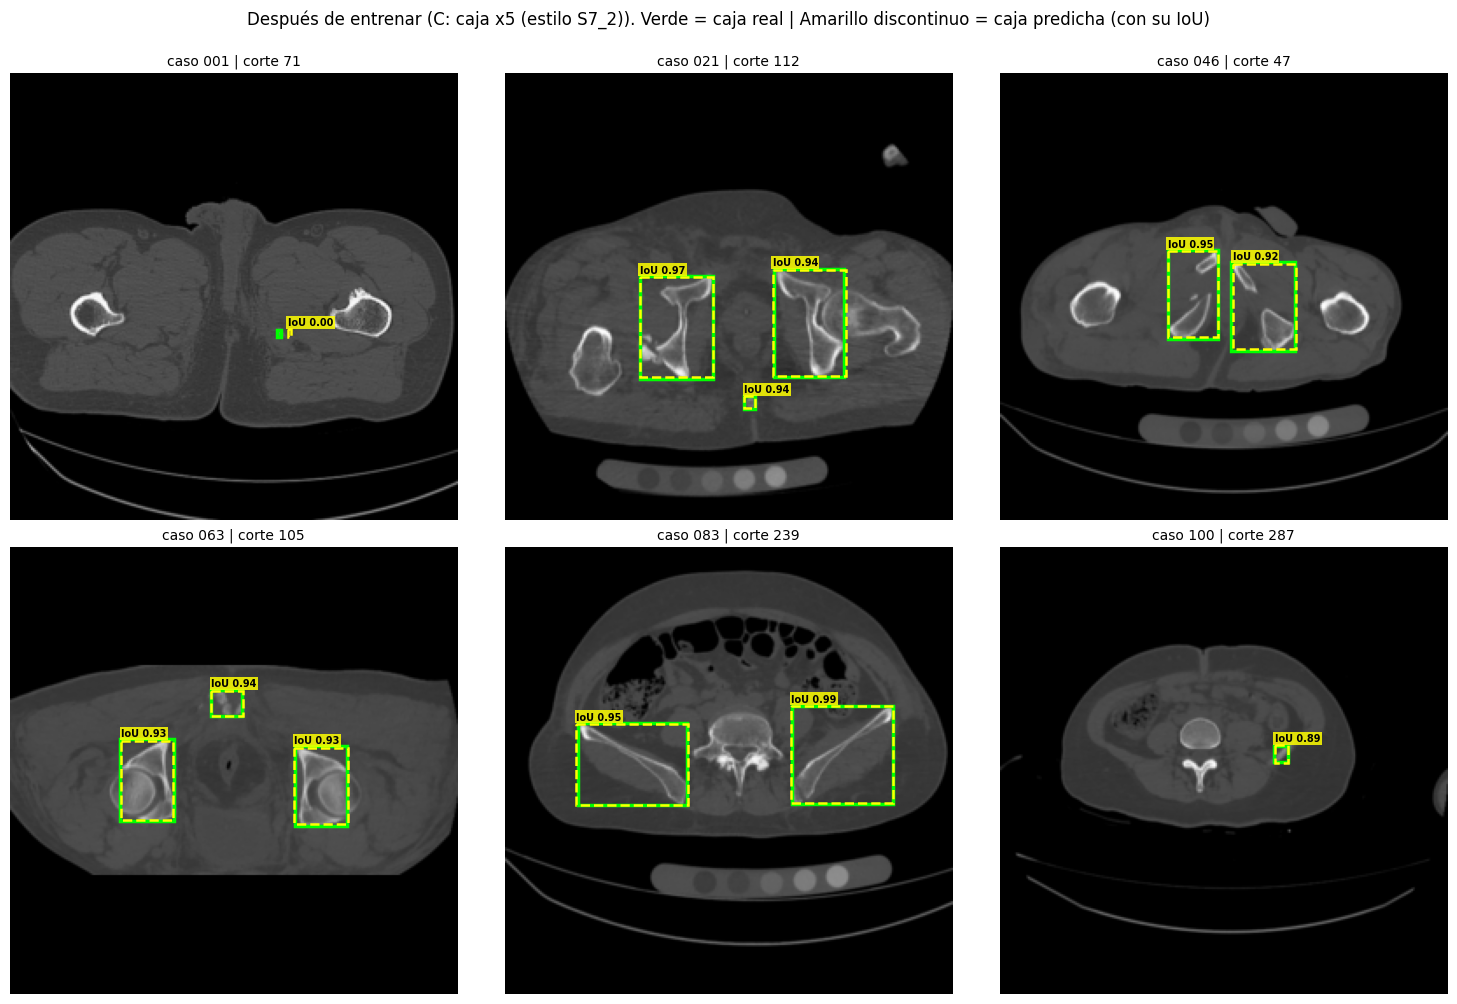

In [23]:
# ---- Elegimos la configuración con mayor IoU final y miramos qué aprendió ----
mejor = max(entrenados, key=lambda n: entrenados[n][1]["mean_iou"][-1])
h_best = entrenados[mejor][0]
print(f"Mayor IoU final: {mejor} ({entrenados[mejor][1]['mean_iou'][-1]:.3f}). Revisa también la tabla: la velocidad de convergencia y los demás términos cuentan.")
with torch.no_grad():
    out_f = h_best(fm)

# Diagnóstico a nivel de celda
prob_f = torch.sigmoid(out_f[:, CH_OBJ]).detach().cpu()
pos_cpu = (T["obj_t"] > 0.5)
pred_pos = prob_f > 0.5
tp, fp, fn = int((pred_pos & pos_cpu).sum()), int((pred_pos & ~pos_cpu).sum()), int((~pred_pos & pos_cpu).sum())
_, _, cls_logit_f = split_head_output(out_f.float().cpu())
acc_cls = (cls_logit_f[pos_cpu].argmax(-1) == T["cls_t"][pos_cpu]).float().mean().item()
print(f"Celdas con P(objeto) > 0.5: {tp} de {int(pos_cpu.sum())} con hueso detectadas | falsos positivos: {fp} | no detectadas: {fn}")
print(f"Exactitud de clase en las celdas con hueso: {acc_cls:.3f}")

# ---- DESPUÉS de entrenar: mapas de probabilidad (misma figura que en la sección 4) ----
fig, axes = plt.subplots(1, 6, figsize=(18, 3.6))
for k, ax in enumerate(axes):
    superponer(ax, imgs[k, 0], prob_f[k], f"caso {targets[k]['case_id']} | máx = {prob_f[k].max():.3f}")
    for b in targets[k]["boxes"]:
        dibujar_caja(ax, b, "white", lw=1.5)
plt.suptitle(f"Después de entrenar ({mejor}): P(objeto) se concentra en las celdas con hueso", y=1.02)
plt.tight_layout()
plt.show()

# ---- DESPUÉS de entrenar: caja real vs caja predicha (misma figura que en la sección 5) ----
dibujar_pred_vs_gt(out_f, T, f"Después de entrenar ({mejor}). Verde = caja real | Amarillo discontinuo = caja predicha (con su IoU)")

In [24]:
@torch.no_grad()
def iou_por_caja(h):
    """IoU de la caja predicha por la celda responsable contra la caja real, para cada una de las 12 cajas."""
    out_ = h(fm).float()
    _, box_logit_, _ = split_head_output(out_)
    b, r, c = [x.to(DEVICE) for x in (T["obj_t"] > 0.5).nonzero(as_tuple=True)]
    b_pred = decode_boxes(r, c, torch.sigmoid(box_logit_[b, r, c]))
    b_gt = decode_boxes(r, c, T["box_t"].to(DEVICE)[b, r, c])
    return box_iou(b_pred, b_gt).cpu(), b.cpu(), r.cpu(), c.cpu()

@torch.no_grad()
def diag_celdas(h):
    """Celdas detectadas, falsos positivos, no detectadas y exactitud de clase (umbral P > 0.5)."""
    out_ = h(fm).float().cpu()
    prob_ = torch.sigmoid(out_[:, CH_OBJ])
    pos_ = T["obj_t"] > 0.5
    pred_ = prob_ > 0.5
    _, _, cls_logit_ = split_head_output(out_)
    acc = (cls_logit_[pos_].argmax(-1) == T["cls_t"][pos_]).float().mean().item()
    return int((pred_ & pos_).sum()), int((pred_ & ~pos_).sum()), int((~pred_ & pos_).sum()), acc

# ---- 1) IoU de cada caja con cada configuración, de la más pequeña a la más grande ----
ious_cfg = {n: iou_por_caja(h)[0] for n, (h, _, _) in entrenados.items()}
_, b_idx, r_idx, c_idx = iou_por_caja(next(iter(entrenados.values()))[0])
filas = []
for i in range(len(b_idx)):
    k, rr_, cc_ = int(b_idx[i]), int(r_idx[i]), int(c_idx[i])
    w_px = float(T["box_t"][k, rr_, cc_, 2]) * IMG_SIZE
    h_px = float(T["box_t"][k, rr_, cc_, 3]) * IMG_SIZE
    filas.append((w_px * h_px, i, k, w_px, h_px, CLASS_NAMES[int(T["cls_t"][k, rr_, cc_]) + 1]))
filas.sort()
print(f"{'caso':<5} {'clase':<16} {'tamaño (px)':>12} " + " ".join(f"{n[0]:>6}" for n in entrenados))
for _, i, k, w_px, h_px, cl in filas:
    print(f"{targets[k]['case_id']:<5} {cl:<16} {w_px:>5.0f} x {h_px:<4.0f} " + " ".join(f"{ious_cfg[n][i].item():>6.2f}" for n in entrenados))

# ---- 2) Diagnóstico a nivel de celda, por configuración ----
print(f"\n{'configuración':<30} {'detectadas':>11} {'falsos pos.':>12} {'no detect.':>11} {'exact. clase':>13}")
for nombre, (h, _, _) in entrenados.items():
    tp, fp, fn, acc = diag_celdas(h)
    print(f"{nombre:<30} {tp:>8}/12 {fp:>12} {fn:>11} {acc:>13.3f}")

# ---- 3) ¿Cuánto ruido hay? Tres semillas por configuración ----
semillas = [SEED, SEED + 1, SEED + 2]
print(f"\n{'configuración':<30} {'IoU (media de los últimos 50 pasos)':>38}   cajas con IoU < 0.5 por semilla")
for nombre, lam in CONFIGS.items():
    finales, fallidas = [], []
    for s in semillas:
        h_s, hist_s, _ = entrenar_cabeza(lam, semilla=s)
        finales.append(float(np.mean(hist_s["mean_iou"][-50:])))
        fallidas.append(int((iou_por_caja(h_s)[0] < 0.5).sum()))
    print(f"{nombre:<30} {np.mean(finales):>20.3f} ± {np.std(finales):.3f}            {fallidas}")

caso  clase             tamaño (px)      A      B      C      D
001   coxal_izquierdo      2 x 4      0.00   0.00   0.00   0.63
021   sacro                6 x 7      0.79   0.94   0.94   0.77
100   coxal_izquierdo      8 x 9      0.90   0.87   0.89   0.82
063   sacro               18 x 15     0.95   0.92   0.94   0.91
063   coxal_derecho       30 x 46     0.84   0.96   0.93   0.92
063   coxal_izquierdo     31 x 47     0.95   0.99   0.93   0.86
046   coxal_derecho       29 x 51     0.91   0.95   0.95   0.77
046   coxal_izquierdo     37 x 51     0.97   0.92   0.92   0.88
021   coxal_derecho       42 x 59     0.97   0.96   0.97   0.87
021   coxal_izquierdo     40 x 62     0.90   0.93   0.94   0.85
083   coxal_derecho       62 x 47     0.90   0.97   0.95   0.87
083   coxal_izquierdo     58 x 56     0.90   0.90   0.99   0.73

configuración                   detectadas  falsos pos.  no detect.  exact. clase
A: todo en 1.0                       12/12            0           0         1.000
B: 

### 6b. GIoU: dar gradiente aunque las cajas no se toquen

En el mini-overfit, la caja de 2×4 px (caso 001) quedó con IoU = 0 en las configuraciones con término IoU: cuando las cajas no se tocan, 1 − IoU es constante y no da gradiente.

**GIoU** (IoU generalizado):

$$GIoU = IoU - \frac{\text{área}(C) - \text{área}(A \cup B)}{\text{área}(C)}$$

donde $C$ es el rectángulo más pequeño que encierra a las dos cajas. Si coinciden, vale 1; si están separadas, es negativo y se acerca a −1 a medida que se alejan. Así, 1 − GIoU sigue disminuyendo cuando la caja predicha se acerca a la real, incluso sin contacto.

**Experimento:** repetimos B y C cambiando (1 − IoU) por (1 − GIoU), con el mismo peso y tres semillas.

OK | G1. cajas idénticas: GIoU = 1                  obtenido=1.000000  esperado=1.000000
OK | G2. una dentro de otra: GIoU = IoU = 0.16      obtenido=0.160000  esperado=0.160000
OK | G3. separadas 10 px: GIoU = -100/300           obtenido=-0.333333  esperado=-0.333333
OK | G4. separadas 80 px: GIoU = -800/1000          obtenido=-0.800000  esperado=-0.800000
OK | G5. cajas separadas: gradiente de (1-IoU) = 0.000 | gradiente de (1-GIoU) = 0.0444


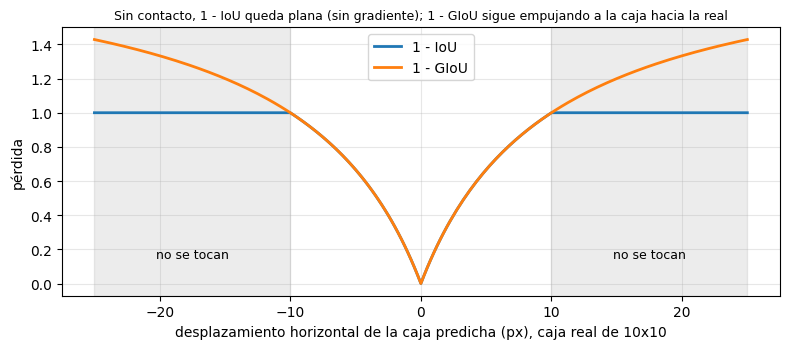

OK | G6. pérdida con GIoU: logits perfectos -> total = 1.36e-08; solo cambia el término de caja

configuración   IoU (media últimos 50 pasos)     IoU de la caja 2x4 por semilla   cajas con IoU < 0.5
B + GIoU                 0.823 ± 0.070                         [0.07, 0.6, 0.13]   [1, 0, 3]
C + GIoU                 0.786 ± 0.059                        [0.04, 0.35, 0.02]   [1, 2, 2]

Referencia sin GIoU (tu corrida anterior): B = 0.840 ± 0.007 y C = 0.832 ± 0.026, ambas con la caja 2x4 fallida en 3 de 3 semillas.


In [25]:
# ---- GIoU: IoU generalizado ----
def box_giou(boxes1, boxes2, eps=1e-7):
    """GIoU elemento a elemento (xyxy) = IoU - (área del rectángulo envolvente - unión) / área del envolvente. Rango [-1, 1]."""
    b1, b2 = boxes1.float(), boxes2.float()
    inter = (torch.minimum(b1[..., 2], b2[..., 2]) - torch.maximum(b1[..., 0], b2[..., 0])).clamp(min=0) * \
            (torch.minimum(b1[..., 3], b2[..., 3]) - torch.maximum(b1[..., 1], b2[..., 1])).clamp(min=0)
    area1 = (b1[..., 2] - b1[..., 0]).clamp(min=0) * (b1[..., 3] - b1[..., 1]).clamp(min=0)
    area2 = (b2[..., 2] - b2[..., 0]).clamp(min=0) * (b2[..., 3] - b2[..., 1]).clamp(min=0)
    union = area1 + area2 - inter
    iou = inter / (union + eps)
    # rectángulo más pequeño que encierra a las dos cajas
    env = (torch.maximum(b1[..., 2], b2[..., 2]) - torch.minimum(b1[..., 0], b2[..., 0])).clamp(min=0) * \
          (torch.maximum(b1[..., 3], b2[..., 3]) - torch.minimum(b1[..., 1], b2[..., 1])).clamp(min=0)
    return iou - (env - union) / (env + eps)


# ---------------- Controles de GIoU ----------------
check("G1. cajas idénticas: GIoU = 1", box_giou(caja(0,0,10,10), caja(0,0,10,10)).item(), 1.0)
check("G2. una dentro de otra: GIoU = IoU = 0.16", box_giou(caja(0,0,10,10), caja(2,2,6,6)).item(), 0.16)
check("G3. separadas 10 px: GIoU = -100/300", box_giou(caja(0,0,10,10), caja(20,0,30,10)).item(), -1/3)
check("G4. separadas 80 px: GIoU = -800/1000", box_giou(caja(0,0,10,10), caja(90,0,100,10)).item(), -0.8)
p_iou = torch.tensor([[20., 0., 30., 10.]], requires_grad=True)
p_giou = torch.tensor([[20., 0., 30., 10.]], requires_grad=True)
(1 - box_iou(p_iou, caja(0, 0, 10, 10))).sum().backward()
(1 - box_giou(p_giou, caja(0, 0, 10, 10))).sum().backward()
assert p_iou.grad.abs().sum().item() == 0.0, "FALLA: se esperaba gradiente cero del IoU con cajas separadas"
assert p_giou.grad.abs().sum().item() > 0.0, "FALLA: GIoU debería dar gradiente con cajas separadas"
print(f"OK | G5. cajas separadas: gradiente de (1-IoU) = {p_iou.grad.abs().sum().item():.3f} | gradiente de (1-GIoU) = {p_giou.grad.abs().sum().item():.4f}")

# Figura: qué pasa al alejar una caja de otra
d = torch.linspace(-25, 25, 201)
gt_rep = torch.tensor([[0., 0., 10., 10.]]).expand(len(d), 4)
pred_rep = torch.stack([d, torch.zeros_like(d), d + 10, torch.full_like(d, 10.)], dim=1)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(d, 1 - box_iou(pred_rep, gt_rep), lw=2, label="1 - IoU")
ax.plot(d, 1 - box_giou(pred_rep, gt_rep), lw=2, label="1 - GIoU")
ax.axvspan(-25, -10, color="gray", alpha=0.15)
ax.axvspan(10, 25, color="gray", alpha=0.15)
ax.text(-17.5, 0.15, "no se tocan", ha="center", fontsize=9)
ax.text(17.5, 0.15, "no se tocan", ha="center", fontsize=9)
ax.set_xlabel("desplazamiento horizontal de la caja predicha (px), caja real de 10x10")
ax.set_ylabel("pérdida")
ax.set_title("Sin contacto, 1 - IoU queda plana (sin gradiente); 1 - GIoU sigue empujando a la caja hacia la real", fontsize=9)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---- Pérdida con GIoU: igual a la de la sección 5, cambiando (1 - IoU) por (1 - GIoU) con el mismo peso ----
def grid_detection_loss_giou(out, tgt, lambdas=LAMBDAS):
    L = dict(LOSS(out, tgt, {**lambdas, "iou": 0.0}))           # todo igual, sin el término IoU normal (box_iou se sigue reportando)
    out_ = out.float()
    _, box_logit_, _ = split_head_output(out_)
    pos = tgt["obj_t"].to(out_.device) > 0.5
    b, r, c = pos.nonzero(as_tuple=True)
    t_pred = torch.sigmoid(box_logit_[b, r, c])
    t_gt = tgt["box_t"].to(out_.device)[b, r, c]
    giou_loss = (1 - box_giou(decode_boxes(r, c, t_pred), decode_boxes(r, c, t_gt))).sum() / pos.sum().clamp(min=1).float()
    L["box_giou"] = giou_loss
    L["box"] = L["box"] + lambdas["iou"] * giou_loss
    L["total"] = L["total"] + lambdas["box"] * lambdas["iou"] * giou_loss
    return L

Lg_p = grid_detection_loss_giou(logits_perfectos(T), T)
assert Lg_p["total"].item() < 1e-2, f"FALLA: con logits perfectos total = {Lg_p['total'].item():.2e}"
with torch.no_grad():
    o_ = head(fm)
    L_iou, L_giou = LOSS(o_, T), grid_detection_loss_giou(o_, T)
diferencia = L_iou["total"].item() - L_giou["total"].item()
esperada = LAMBDAS["box"] * LAMBDAS["iou"] * (L_iou["box_iou"].item() - L_giou["box_giou"].item())
assert abs(diferencia - esperada) < 1e-4, "FALLA: la única diferencia entre las dos pérdidas debe ser el término de caja"
print(f"OK | G6. pérdida con GIoU: logits perfectos -> total = {Lg_p['total'].item():.2e}; solo cambia el término de caja")


# ---- Experimento: B y C con GIoU, tres semillas ----
def entrenar_cabeza(lambdas, pasos=400, lr=2e-3, semilla=SEED, loss_fn=None):
    """Igual que antes, pero se puede elegir la función de pérdida (por defecto, la de la sección 5)."""
    loss_fn = LOSS if loss_fn is None else loss_fn
    torch.manual_seed(semilla)
    h = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
    opt = torch.optim.AdamW(h.parameters(), lr=lr, weight_decay=0.0)
    hist = {k: [] for k in ("total", "obj", "box_l1", "box_iou", "cls", "mean_iou")}
    t0 = time.perf_counter()
    for paso in range(pasos + 1):
        L = loss_fn(h(fm), T, lambdas)
        for k in hist:
            hist[k].append(L[k].item())
        if paso == pasos:
            break
        opt.zero_grad()
        L["total"].backward()
        opt.step()
    return h, hist, time.perf_counter() - t0

i_min = filas[0][1]                                              # índice de la caja más pequeña (2 x 4 px, caso 001)
EXPERIMENTOS = {
    "B + GIoU": (CONFIGS["B: equilibrio de magnitudes"], grid_detection_loss_giou),
    "C + GIoU": (CONFIGS["C: caja x5 (estilo S7_2)"], grid_detection_loss_giou),
}
print(f"\n{'configuración':<12} {'IoU (media últimos 50 pasos)':>30}   {'IoU de la caja 2x4 por semilla':>32}   cajas con IoU < 0.5")
giou_entrenados = {}
for nombre, (lam, fn) in EXPERIMENTOS.items():
    finales, minis, fallidas = [], [], []
    for s in semillas:
        h_s, hist_s, _ = entrenar_cabeza(lam, semilla=s, loss_fn=fn)
        ious_s = iou_por_caja(h_s)[0]
        finales.append(float(np.mean(hist_s["mean_iou"][-50:])))
        minis.append(round(ious_s[i_min].item(), 2))
        fallidas.append(int((ious_s < 0.5).sum()))
        if s == SEED:
            giou_entrenados[nombre] = (h_s, hist_s, lam)
    print(f"{nombre:<12} {np.mean(finales):>17.3f} ± {np.std(finales):.3f}          {str(minis):>32}   {fallidas}")
print("\nReferencia sin GIoU (tu corrida anterior): B = 0.840 ± 0.007 y C = 0.832 ± 0.026, ambas con la caja 2x4 fallida en 3 de 3 semillas.")

configuración                         IoU (media últimos 50 pasos)     IoU de la caja 2x4 por semilla   cajas < 0.5  seg/corrida
B, 400 pasos, lr constante (ref.)                  0.840 ± 0.007                    [0.0, 0.0, 0.0]   [1, 1, 1]            8.5
B, 400 pasos, lr con decaimiento                   0.856 ± 0.077                    [0.0, 0.0, 0.0]   [1, 1, 3]            7.0
B, 1200 pasos, lr con decaimiento                  0.917 ± 0.000                    [0.0, 0.0, 0.0]   [1, 1, 1]           22.7


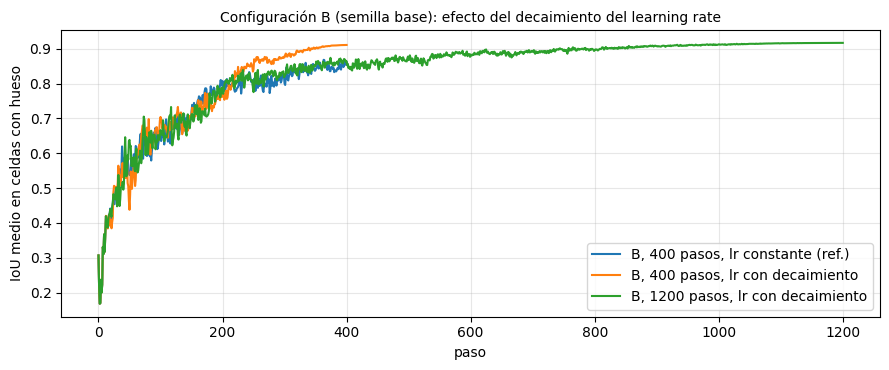


LAMBDAS_FINAL = {'obj': 0.46, 'box': 2.9, 'cls': 2.03, 'noobj': 1.0, 'l1': 1.0, 'iou': 1.0}


In [26]:
def entrenar_cabeza(lambdas, pasos=400, lr=2e-3, semilla=SEED, loss_fn=None, decaer=False):
    """Entrena SOLO la cabeza sobre los features fijos `fm`. loss_fn: función de pérdida (por defecto la de la sección 5).
    decaer=True: el learning rate baja de lr a 0 siguiendo un coseno a lo largo de los pasos."""
    loss_fn = LOSS if loss_fn is None else loss_fn
    torch.manual_seed(semilla)
    h = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
    opt = torch.optim.AdamW(h.parameters(), lr=lr, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pasos) if decaer else None
    hist = {k: [] for k in ("total", "obj", "box_l1", "box_iou", "cls", "mean_iou")}
    t0 = time.perf_counter()
    for paso in range(pasos + 1):
        L = loss_fn(h(fm), T, lambdas)
        for k in hist:
            hist[k].append(L[k].item())
        if paso == pasos:
            break
        opt.zero_grad()
        L["total"].backward()
        opt.step()
        if sched is not None:
            sched.step()
    return h, hist, time.perf_counter() - t0


CONFIG_B = CONFIGS["B: equilibrio de magnitudes"]
EXPERIMENTOS_LR = {
    "B, 400 pasos, lr constante (ref.)": dict(pasos=400, decaer=False),
    "B, 400 pasos, lr con decaimiento": dict(pasos=400, decaer=True),
    "B, 1200 pasos, lr con decaimiento": dict(pasos=1200, decaer=True),
}
print(f"{'configuración':<36} {'IoU (media últimos 50 pasos)':>29}   {'IoU de la caja 2x4 por semilla':>32}   {'cajas < 0.5':<12} {'seg/corrida':>11}")
lr_entrenados = {}
for nombre, kw in EXPERIMENTOS_LR.items():
    finales, minis, fallidas, tiempos = [], [], [], []
    for s in semillas:
        h_s, hist_s, seg = entrenar_cabeza(CONFIG_B, semilla=s, **kw)
        ious_s = iou_por_caja(h_s)[0]
        finales.append(float(np.mean(hist_s["mean_iou"][-50:])))
        minis.append(round(ious_s[i_min].item(), 2))
        fallidas.append(int((ious_s < 0.5).sum()))
        tiempos.append(seg)
        if s == SEED:
            lr_entrenados[nombre] = (h_s, hist_s)
    print(f"{nombre:<36} {np.mean(finales):>19.3f} ± {np.std(finales):.3f}   {str(minis):>32}   {str(fallidas):<12} {np.mean(tiempos):>11.1f}")

# ---- Curvas de la semilla base: ¿el decaimiento calma el ruido? ----
fig, ax = plt.subplots(figsize=(9, 3.8))
for nombre, (h_s, hist_s) in lr_entrenados.items():
    ax.plot(hist_s["mean_iou"], label=nombre, lw=1.5)
ax.set_xlabel("paso")
ax.set_ylabel("IoU medio en celdas con hueso")
ax.set_title("Configuración B (semilla base): efecto del decaimiento del learning rate", fontsize=10)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Lambda finales elegidos (documentar en el informe: 4 configuraciones x 3 semillas, GIoU descartado) ----
LAMBDAS_FINAL = dict(CONFIG_B)
print("\nLAMBDAS_FINAL =", {k: round(v, 2) for k, v in LAMBDAS_FINAL.items()})

In [27]:
def diagnostico_caja(h, i, titulo, b_all=b_idx, r_all=r_idx, c_all=c_idx):
    """Qué predice una cabeza entrenada para la caja i (la de 2x4 px) y qué fuerza recibe de cada término de la pérdida de caja."""
    out_ = h(fm).float()
    L_ = LOSS(out_, T, LAMBDAS)                                   # los términos box_l1 y box_iou salen sin ponderar
    g_l1 = torch.autograd.grad(L_["box_l1"], out_, retain_graph=True)[0]
    g_iou = torch.autograd.grad(L_["box_iou"], out_, retain_graph=True)[0]
    b, r, c = int(b_all[i]), int(r_all[i]), int(c_all[i])
    tp = torch.sigmoid(out_[b, 1:5, r, c]).detach()[None]         # [1,4] predicho (tx, ty, tw, th)
    tg = T["box_t"][b, r, c][None].to(out_.device)                # [1,4] real
    ri, ci = torch.tensor([r]), torch.tensor([c])
    bp, bg = decode_boxes(ri, ci, tp)[0], decode_boxes(ri, ci, tg)[0]
    centro = lambda bx: (((bx[0] + bx[2]) / 2).item(), ((bx[1] + bx[3]) / 2).item())
    (cxp, cyp), (cxg, cyg) = centro(bp), centro(bg)
    print(f"== {titulo} ==")
    print(f"caja real  : centro ({cxg:6.1f}, {cyg:6.1f}) px | tamaño {(bg[2] - bg[0]).item():5.1f} x {(bg[3] - bg[1]).item():5.1f} px")
    print(f"caja pred. : centro ({cxp:6.1f}, {cyp:6.1f}) px | tamaño {(bp[2] - bp[0]).item():5.1f} x {(bp[3] - bp[1]).item():5.1f} px")
    print(f"error de centro: dx = {cxp - cxg:+.1f} px, dy = {cyp - cyg:+.1f} px | IoU = {box_iou(bp[None], bg[None]).item():.3f}")
    gc1 = g_l1[b, 1:5, r, c]
    gc2 = g_iou[b, 1:5, r, c]
    prom1 = g_l1[b_all, 1:5, r_all, c_all].abs().mean(0)          # magnitud media de las 12 celdas, por canal
    prom2 = g_iou[b_all, 1:5, r_all, c_all].abs().mean(0)
    f4 = lambda x: "[" + ", ".join(f"{v:+.1e}" for v in x.tolist()) + "]"
    print(f"gradiente de L1 sobre los logits [tx, ty, tw, th] de esa celda : {f4(gc1)}   (|media| de las 12 celdas: {f4(prom1)})")
    print(f"gradiente de 1-IoU sobre esos mismos logits                    : {f4(gc2)}   (|media| de las 12 celdas: {f4(prom2)})")
    print()

diagnostico_caja(lr_entrenados["B, 1200 pasos, lr con decaimiento"][0], i_min, "B, 1200 pasos con decaimiento (IoU de la caja 2x4 = 0)")
h_D, _, lam_D = entrenados["D: sin término IoU (solo L1)"]
diagnostico_caja(h_D, i_min, "D, 400 pasos, solo L1 (rescató la caja 2x4 en 2 de 3 semillas)")

== B, 1200 pasos con decaimiento (IoU de la caja 2x4 = 0) ==
caja real  : centro ( 154.0,  149.0) px | tamaño   2.0 x   4.0 px
caja pred. : centro ( 160.0,  149.0) px | tamaño   2.0 x   4.0 px
error de centro: dx = +6.0 px, dy = -0.0 px | IoU = 0.000
gradiente de L1 sobre los logits [tx, ty, tw, th] de esa celda : [+1.9e-06, -4.5e-03, -1.6e-04, +3.2e-04]   (|media| de las 12 celdas: [+2.4e-03, +3.8e-03, +2.1e-03, +2.5e-03])
gradiente de 1-IoU sobre esos mismos logits                    : [+0.0e+00, +0.0e+00, +0.0e+00, +0.0e+00]   (|media| de las 12 celdas: [+4.5e-03, +5.9e-04, +5.4e-02, +6.1e-02])

== D, 400 pasos, solo L1 (rescató la caja 2x4 en 2 de 3 semillas) ==
caja real  : centro ( 154.0,  149.0) px | tamaño   2.0 x   4.0 px
caja pred. : centro ( 154.4,  148.8) px | tamaño   1.9 x   4.1 px
error de centro: dx = +0.4 px, dy = -0.2 px | IoU = 0.631
gradiente de L1 sobre los logits [tx, ty, tw, th] de esa celda : [+4.8e-03, -4.4e-03, -1.5e-04, +3.3e-04]   (|media| de las 12 celdas: 